# Exploratory Data Analysis - 05_29_26

In [1]:
# Data Import
import sys
sys.path.append('../Data_Processing')
from full_cleaning_preprocessing_script import run_full_preprocessing

# General
import pandas as pd
import numpy as np
import os
from typing import List
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

Taking data from the longest period where we have complete data. Looking at the final file 2024 ends with the highest level of data, limited by the lake data.

In [2]:
df = run_full_preprocessing(
    data_folder = "/home/jpelletier/Downloads/data",
    start_date = "2014-01-01",
    end_date = "2024-12-31"
)

DUCKSTRADAMUS — FULL PREPROCESSING PIPELINE
  data_folder : /home/jpelletier/Downloads/data
  date range  : 2014-01-01  →  2024-12-31
  save_path   : None

[1/9] Wholesale price...
      Anchor df shape: (96408, 10)

[2/9] Generation output...
      Shape after merge: (96408, 19)

[3/9] Wind...
      Shape after merge: (96408, 29)

[4/9] Solar...
      Shape after merge: (96408, 41)

[5/9] Temperature...
      Shape after merge: (96408, 47)

[6/9] Lake storage...
      Merged: NI_TPO_Storage_LakeTaupo.csv  (prefix: 'NI_TPO_')
      Merged: NI_WKA_Storage_LakeWaikaremoana.csv  (prefix: 'NI_WKA_')
      Merged: SI_HWE_Storage_LakeHawea.csv  (prefix: 'SI_HWE_')
      Merged: SI_MAN_Storage_LakeManapouri.csv  (prefix: 'SI_MAN_')
      Merged: SI_OHA_Storage_LakeOhau.csv  (prefix: 'SI_OHA_')
      Merged: SI_PKI_Storage_LakePukaki.csv  (prefix: 'SI_PKI_')
      Merged: SI_TAU_Storage_LakeTeAnau.csv  (prefix: 'SI_TAU_')
      Merged: SI_TKA_Storage_LakeTekapo.csv  (prefix: 'SI_TKA_')
      M

# A. Overall Data & Target Analysis

## 0. Add New Features as Totals

In [3]:
demand_cols = [col for col in df.columns if 'demand' in col.lower()]
df["total_demand"] = df[demand_cols].sum(axis=1)

lake_cols = [col for col in df.columns if 'storage' in col.lower()]
df["total_lakes"] = df[lake_cols].sum(axis=1)

df["total_wind"] = df[['palmerston_north_wind_kmh', 'wellington_wind_kmh', 'harapaki_hawkesbay_wind_kmh', 'te_uku_waikato_wind_kmh', 'kaiwera_downs_southland_wind_kmh']].sum(axis=1)

solar_cols = [col for col in df.columns if 'sunshine' in col.lower() or 'shortwave' in col.lower()]
df['total_solar'] = df[solar_cols].sum(axis=1)

## 1. Basic Information

In [4]:
print(df.shape)
print(df.info())

(96408, 85)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96408 entries, 0 to 96407
Data columns (total 85 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   datetime_utc12                        96408 non-null  datetime64[ns]
 1   el_price_dol_MWh_BEN2201              96408 non-null  float64       
 2   el_price_dol_MWh_HAY2201              96408 non-null  float64       
 3   el_price_dol_MWh_INV2201              96408 non-null  float64       
 4   el_price_dol_MWh_ISL2201              96408 non-null  float64       
 5   el_price_dol_MWh_KIK2201              59888 non-null  float64       
 6   el_price_dol_MWh_OTA2201              96408 non-null  float64       
 7   el_price_dol_MWh_RDF2201              96408 non-null  float64       
 8   el_price_dol_MWh_SFD2201              96408 non-null  float64       
 9   el_price_dol_MWh_WKM2201              96408 non-null  float6

In [5]:
df.describe()

,datetime_utc12,el_price_dol_MWh_BEN2201,el_price_dol_MWh_HAY2201,el_price_dol_MWh_INV2201,el_price_dol_MWh_ISL2201,el_price_dol_MWh_KIK2201,el_price_dol_MWh_OTA2201,el_price_dol_MWh_RDF2201,el_price_dol_MWh_SFD2201,el_price_dol_MWh_WKM2201,...,Direction,outage_Gas_MW,outage_Hyd_MW,outage_Ter_MW,outage_Win_MW,outage_UNKN_MW,total_demand,total_lakes,total_wind,total_solar
count,96408,96408.000000,96408.000000,96408.000000,96408.000000,59888.000000,96408.000000,96408.000000,96408.000000,96408.000000,...,96397.000000,96397.000000,96397.000000,96397.000000,96397.000000,96397.000000,96408.000000,96408.000000,96408.000000,96408.000000
mean,2019-07-02 12:06:49.727408640,103.242942,108.405246,104.653481,110.740273,139.552865,115.036394,109.111459,107.636188,108.901645,...,0.649657,50.486090,547.120971,432.571199,56.121844,33.448018,4.699324,4741.216675,123.165164,9329.537233
min,2014-01-01 00:00:00,0.000000,0.005000,-0.030000,0.000000,0.000000,0.005000,0.005000,0.005000,0.005000,...,-1.000000,0.000000,35.200000,0.400000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2016-10-01 05:45:00,49.460000,53.205000,48.203750,52.340000,62.305000,57.545000,54.768750,54.420000,54.685000,...,1.000000,11.000000,384.500000,268.000000,16.250000,2.000000,4.023000,4016.456656,89.900000,0.000000
50%,2019-07-02 12:30:00,76.600000,81.180000,76.665000,81.747500,113.705000,86.525000,82.340000,81.622500,82.200000,...,1.000000,30.000000,527.000000,375.000000,39.600000,7.000000,4.788000,4711.294146,117.900000,1156.295000
75%,2022-04-01 18:15:00,131.320000,137.516250,133.112500,141.076250,187.246250,147.941250,140.231250,137.425000,139.996250,...,1.000000,65.000000,677.900000,568.000000,66.200000,44.000000,5.266000,5493.241563,151.300000,20393.000000
max,2024-12-31 00:00:00,5011.380000,5447.860000,5034.110000,5533.795000,4334.935000,6046.320000,5452.295000,5621.680000,5542.435000,...,1.000000,403.200000,1914.200000,1343.000000,550.220000,435.600000,7.246000,8656.800000,320.200000,27934.000000
std,NaN,98.394992,102.975282,101.288848,106.952779,127.756929,107.964600,102.458412,100.004761,101.081348,...,0.756044,57.008669,234.577745,222.409813,56.801238,70.368730,0.802557,1041.585541,44.592169,10359.861667


In [6]:
df.isnull().sum()[df.isnull().sum()>0]

el_price_dol_MWh_KIK2201    36520
Coal                           32
Diesel                         32
Ele                            32
Gas                            32
                            ...  
outage_Gas_MW                  11
outage_Hyd_MW                  11
outage_Ter_MW                  11
outage_Win_MW                  11
outage_UNKN_MW                 11
Length: 67, dtype: int64

## 2. Target Variable Distribution

Text(0, 0.5, 'Frequency (log scale)')

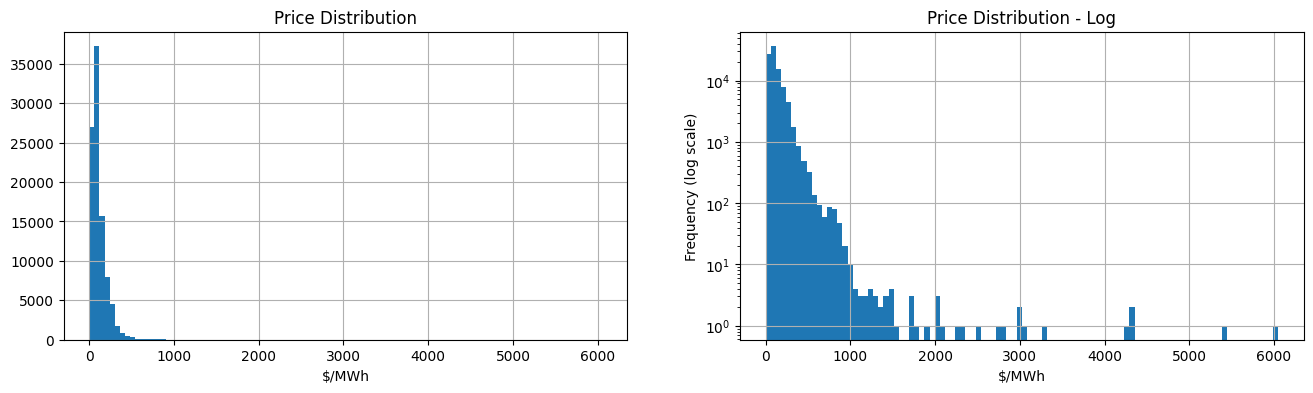

In [7]:
plt.figure(figsize=(16, 4))

plt.subplot(1, 2, 1)
df['el_price_dol_MWh_OTA2201'].hist(bins=100)
plt.title('Price Distribution')
plt.xlabel('$/MWh')

plt.subplot(1, 2, 2)
df['el_price_dol_MWh_OTA2201'].hist(bins=100)
plt.yscale('log')
plt.title('Price Distribution - Log')
plt.xlabel('$/MWh')
plt.ylabel('Frequency (log scale)')

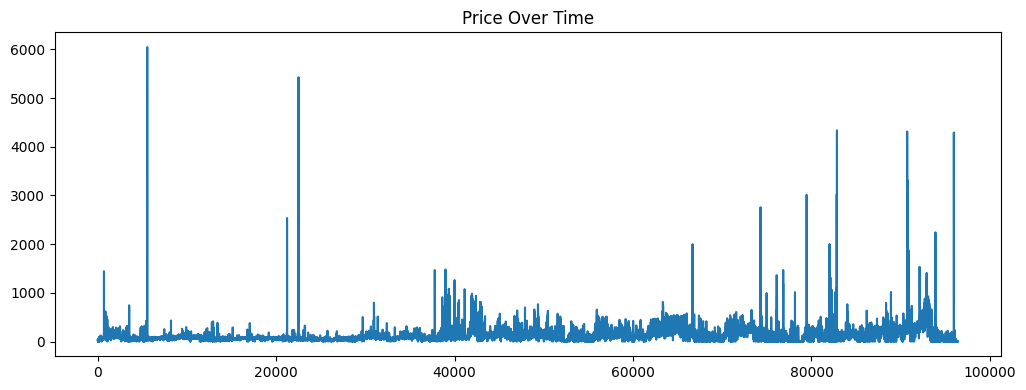

In [8]:
plt.figure(figsize=(20, 4))
plt.subplot(1, 2, 2)
df['el_price_dol_MWh_OTA2201'].plot()
plt.title('Price Over Time')
plt.tight_layout()
plt.show()

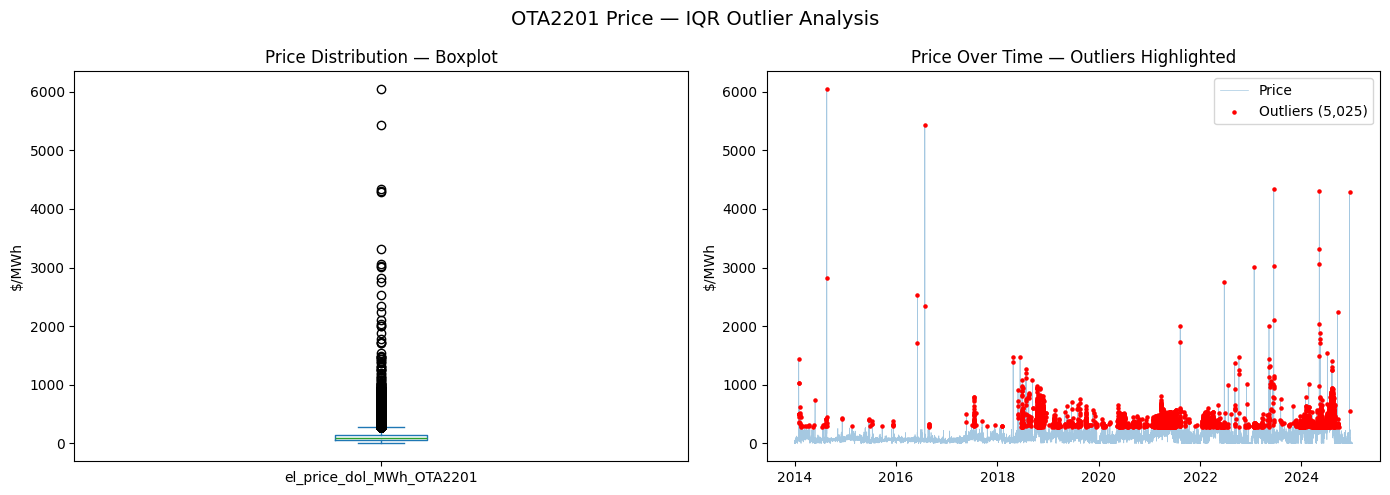

IQR bounds  : [-78.05, 283.54]
Total outliers: 5,025 (5.21% of data)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
df['el_price_dol_MWh_OTA2201'].plot(kind='box', ax=axes[0])
axes[0].set_title('Price Distribution — Boxplot')
axes[0].set_ylabel('$/MWh')

# Identify outliers using IQR method
Q1  = df['el_price_dol_MWh_OTA2201'].quantile(0.25)
Q3  = df['el_price_dol_MWh_OTA2201'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['el_price_dol_MWh_OTA2201'] < lower) |
    (df['el_price_dol_MWh_OTA2201'] > upper)
]

# Plot with outliers highlighted
axes[1].plot(df['datetime_utc12'], df['el_price_dol_MWh_OTA2201'], alpha=0.4, linewidth=0.5, label='Price')
axes[1].scatter(outliers['datetime_utc12'], outliers['el_price_dol_MWh_OTA2201'],
                color='red', s=5, label=f'Outliers ({len(outliers):,})', zorder=5)
axes[1].set_title('Price Over Time — Outliers Highlighted')
axes[1].set_ylabel('$/MWh')
axes[1].legend()

plt.suptitle('OTA2201 Price — IQR Outlier Analysis', fontsize=14)
plt.tight_layout()
plt.show()

print(f'IQR bounds  : [{lower:.2f}, {upper:.2f}]')
print(f'Total outliers: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}% of data)')

In [10]:
df[df["el_price_dol_MWh_OTA2201"] > 1000].shape

(55, 85)

In [11]:
df.shape

(96408, 85)

## 3. Target over time — zoom into one year to see patterns

1 Year

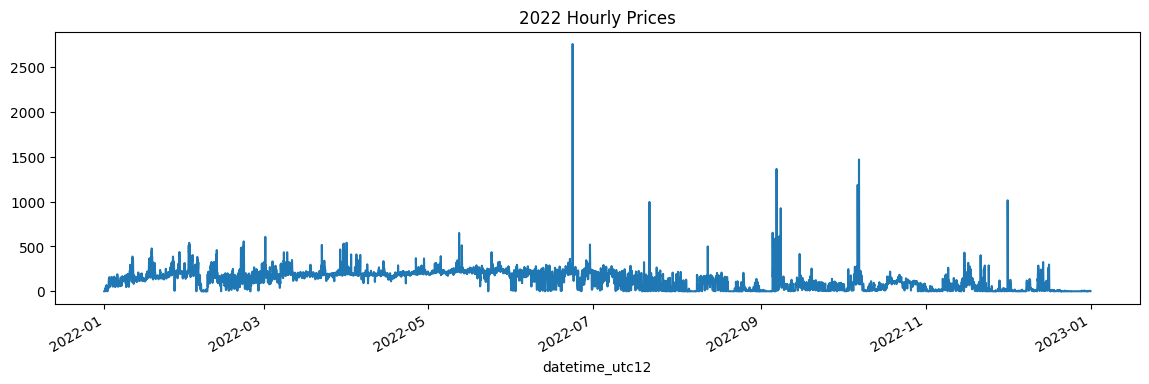

In [12]:
df[pd.to_datetime(df['datetime_utc12']).dt.year == 2022].set_index('datetime_utc12')['el_price_dol_MWh_OTA2201'].plot(figsize=(14, 4))
plt.title('2022 Hourly Prices')
plt.show()

4 Years

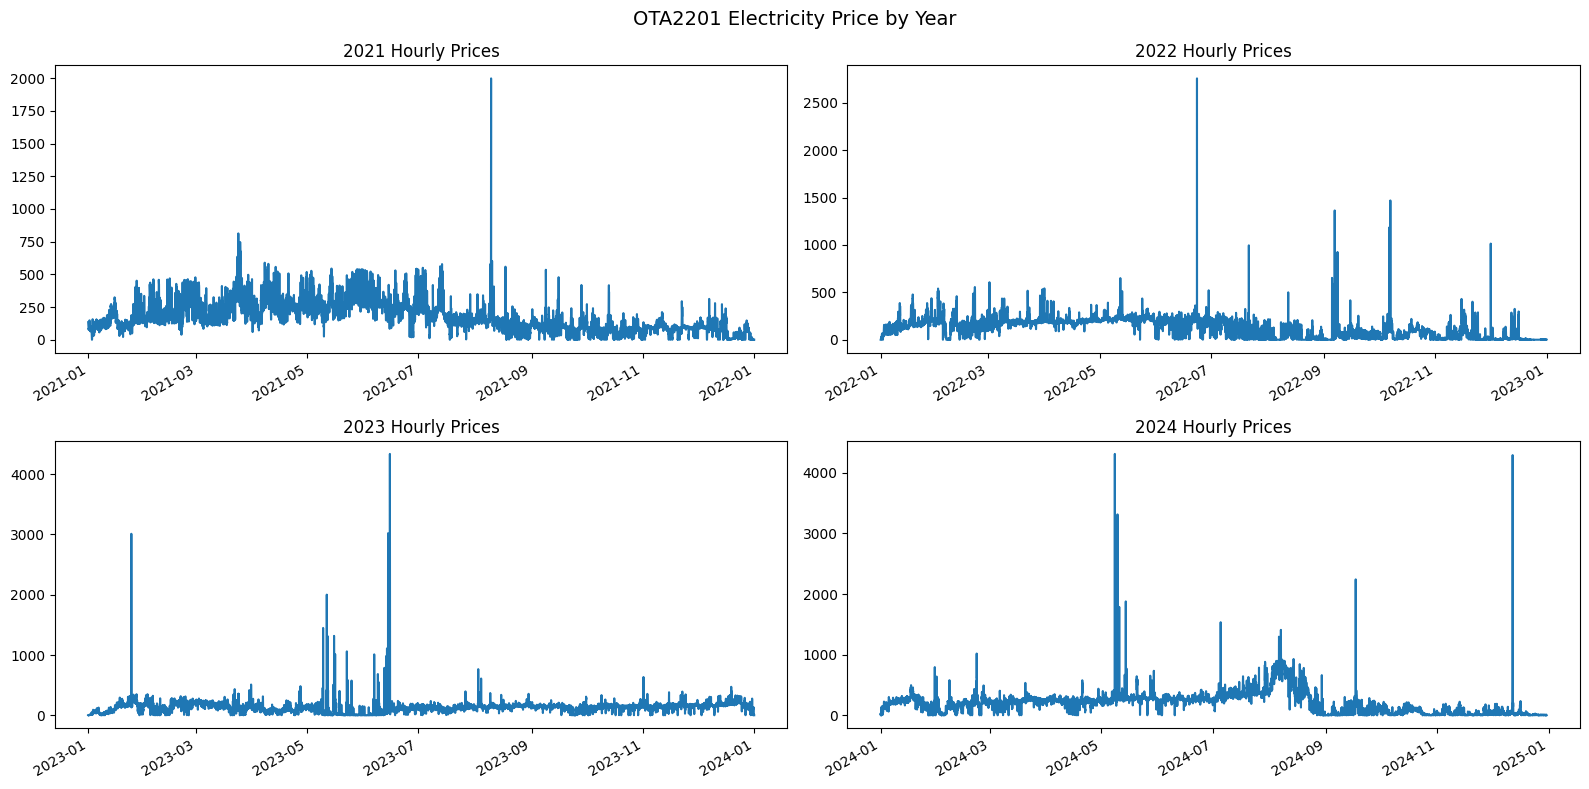

In [13]:
years = [2021, 2022, 2023, 2024]

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()

for i, year in enumerate(years):
    mask = pd.to_datetime(df['datetime_utc12']).dt.year == year
    df[mask].set_index('datetime_utc12')['el_price_dol_MWh_OTA2201'].plot(ax=axes[i])
    axes[i].set_title(f'{year} Hourly Prices')
    axes[i].set_xlabel('')

plt.suptitle('OTA2201 Electricity Price by Year', fontsize=14)
plt.tight_layout()
plt.show()

6 Years

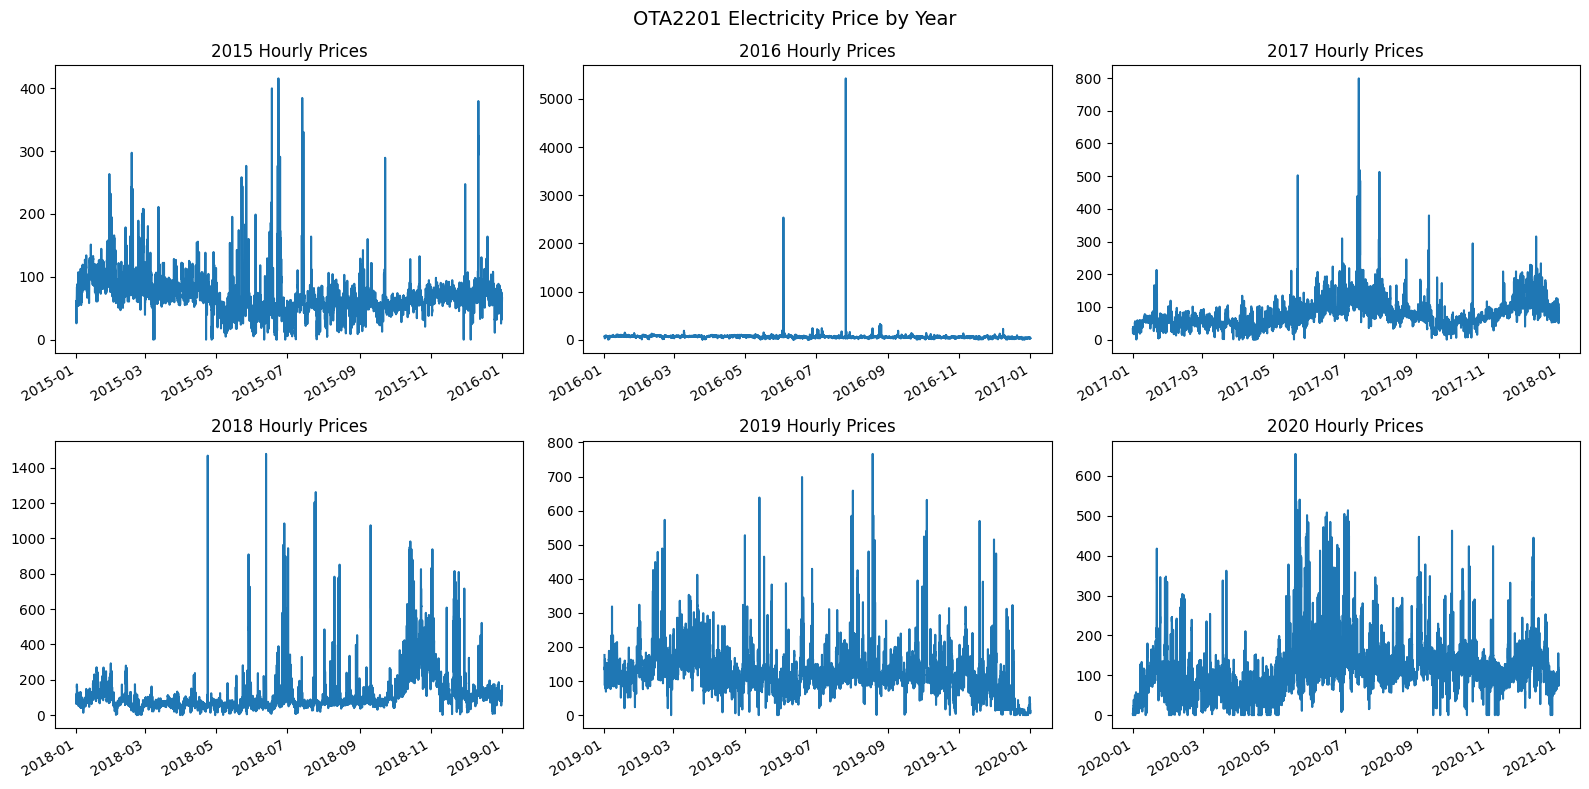

In [14]:
years = [2015, 2016, 2017, 2018, 2019, 2020]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, year in enumerate(years):
    mask = pd.to_datetime(df['datetime_utc12']).dt.year == year
    df[mask].set_index('datetime_utc12')['el_price_dol_MWh_OTA2201'].plot(ax=axes[i])
    axes[i].set_title(f'{year} Hourly Prices')
    axes[i].set_xlabel('')

plt.suptitle('OTA2201 Electricity Price by Year', fontsize=14)
plt.tight_layout()
plt.show()

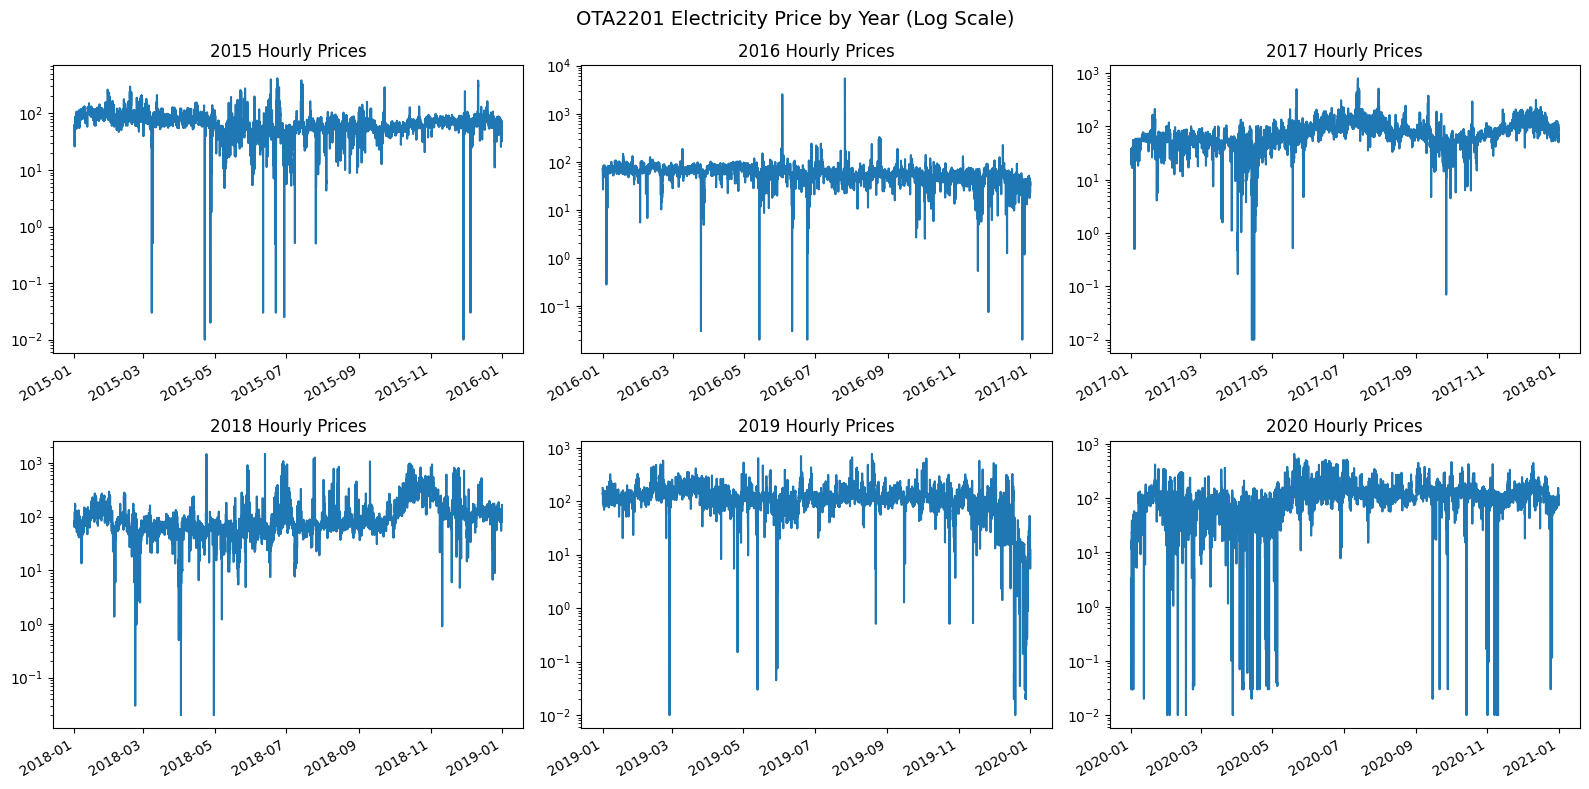

In [15]:
years = [2015, 2016, 2017, 2018, 2019, 2020]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, year in enumerate(years):
    mask = pd.to_datetime(df['datetime_utc12']).dt.year == year

    df[mask].set_index('datetime_utc12')['el_price_dol_MWh_OTA2201'].plot(ax=axes[i])

    axes[i].set_yscale('log')  # Log scale
    axes[i].set_title(f'{year} Hourly Prices')
    axes[i].set_xlabel('')

plt.suptitle('OTA2201 Electricity Price by Year (Log Scale)', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Seasonality checks

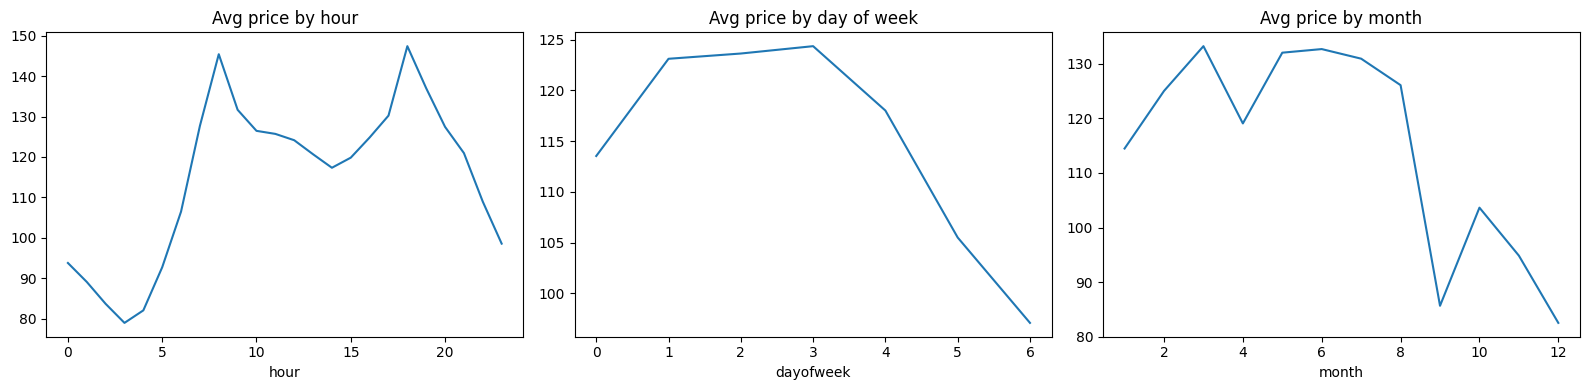

In [16]:
df['hour']       = pd.to_datetime(df['datetime_utc12']).dt.hour
df['dayofweek']  = pd.to_datetime(df['datetime_utc12']).dt.dayofweek
df['month']      = pd.to_datetime(df['datetime_utc12']).dt.month

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df.groupby('hour')['el_price_dol_MWh_OTA2201'].mean().plot(ax=axes[0], title='Avg price by hour')
df.groupby('dayofweek')['el_price_dol_MWh_OTA2201'].mean().plot(ax=axes[1], title='Avg price by day of week')
df.groupby('month')['el_price_dol_MWh_OTA2201'].mean().plot(ax=axes[2], title='Avg price by month')
plt.tight_layout()
plt.show()

# B. Features Analysis: Heatmap, Correlation, Feature Selection

## 1. Correlations

### Target Correlation

In [ ]:
# Dropping day of the week, hour, and month
df = df.drop(columns=['hour', 'dayofweek', 'month'])

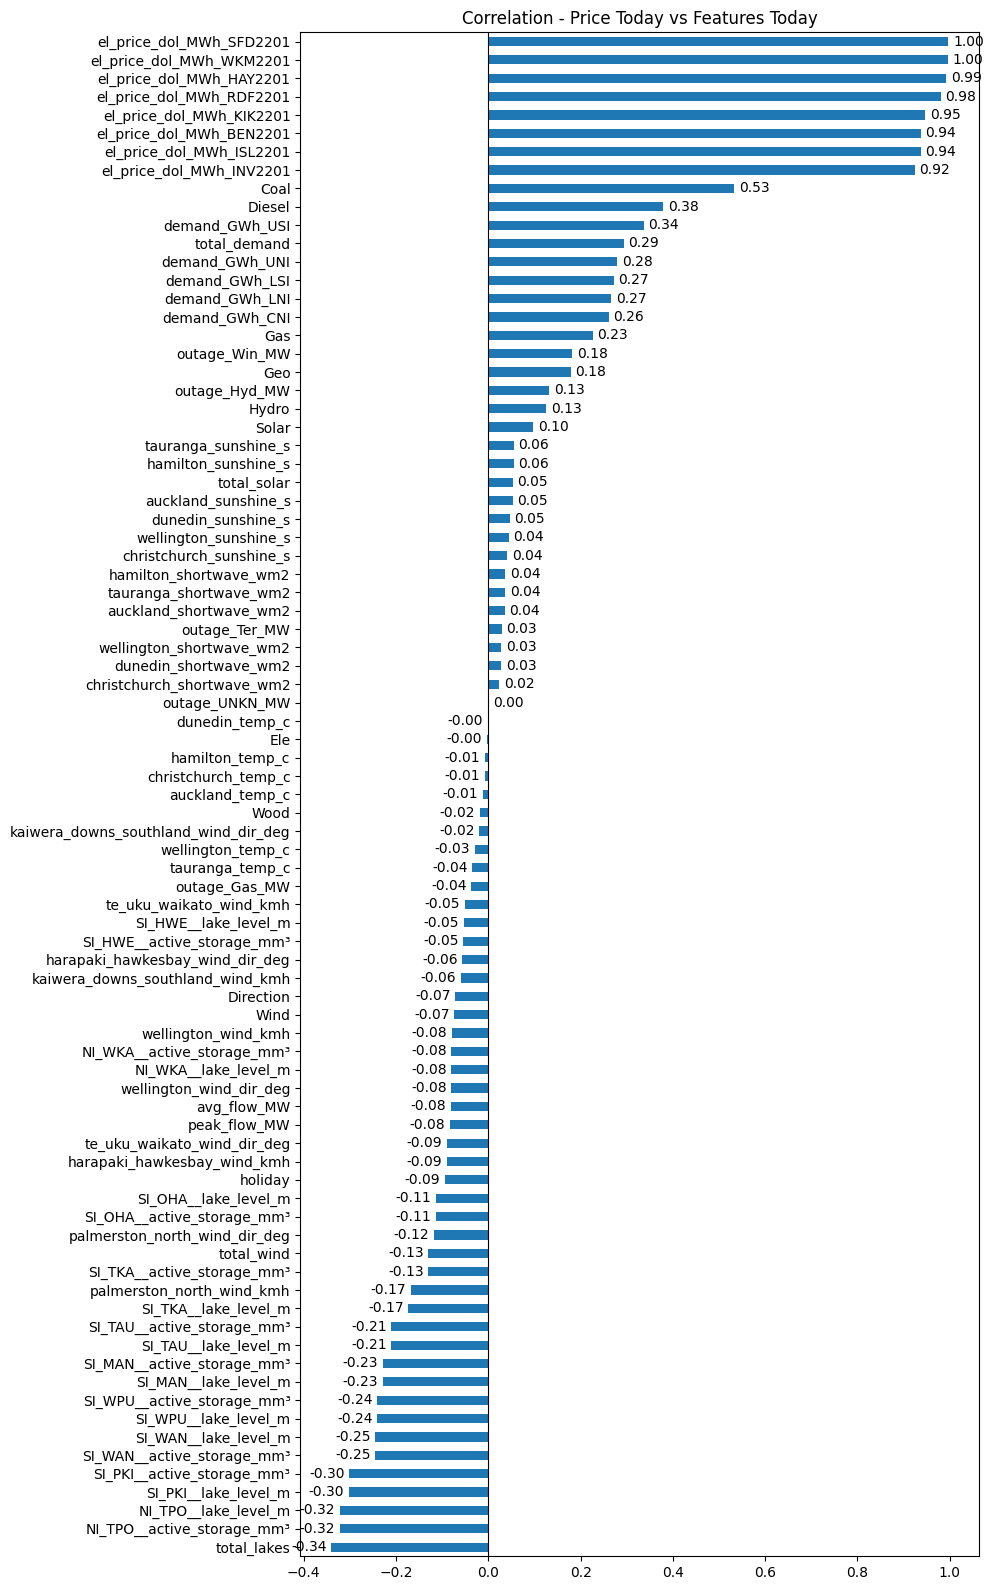

In [19]:
# Top correlations with target
corr = df.select_dtypes(include='number').corr()
target_corr = corr['el_price_dol_MWh_OTA2201'].drop('el_price_dol_MWh_OTA2201').sort_values()

fig, ax = plt.subplots(figsize=(10, 16))

target_corr.plot(kind='barh', ax=ax)

# Add labels
for i, value in enumerate(target_corr):
    ax.text(
        value + (0.01 if value >= 0 else -0.01),  # offset
        i,
        f'{value:.2f}',
        va='center',
        ha='left' if value >= 0 else 'right'
    )

ax.set_title('Correlation - Price Today vs Features Today')
ax.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

### 24h & 72h Lagged Correlation

In [20]:
target = "el_price_dol_MWh_OTA2201"

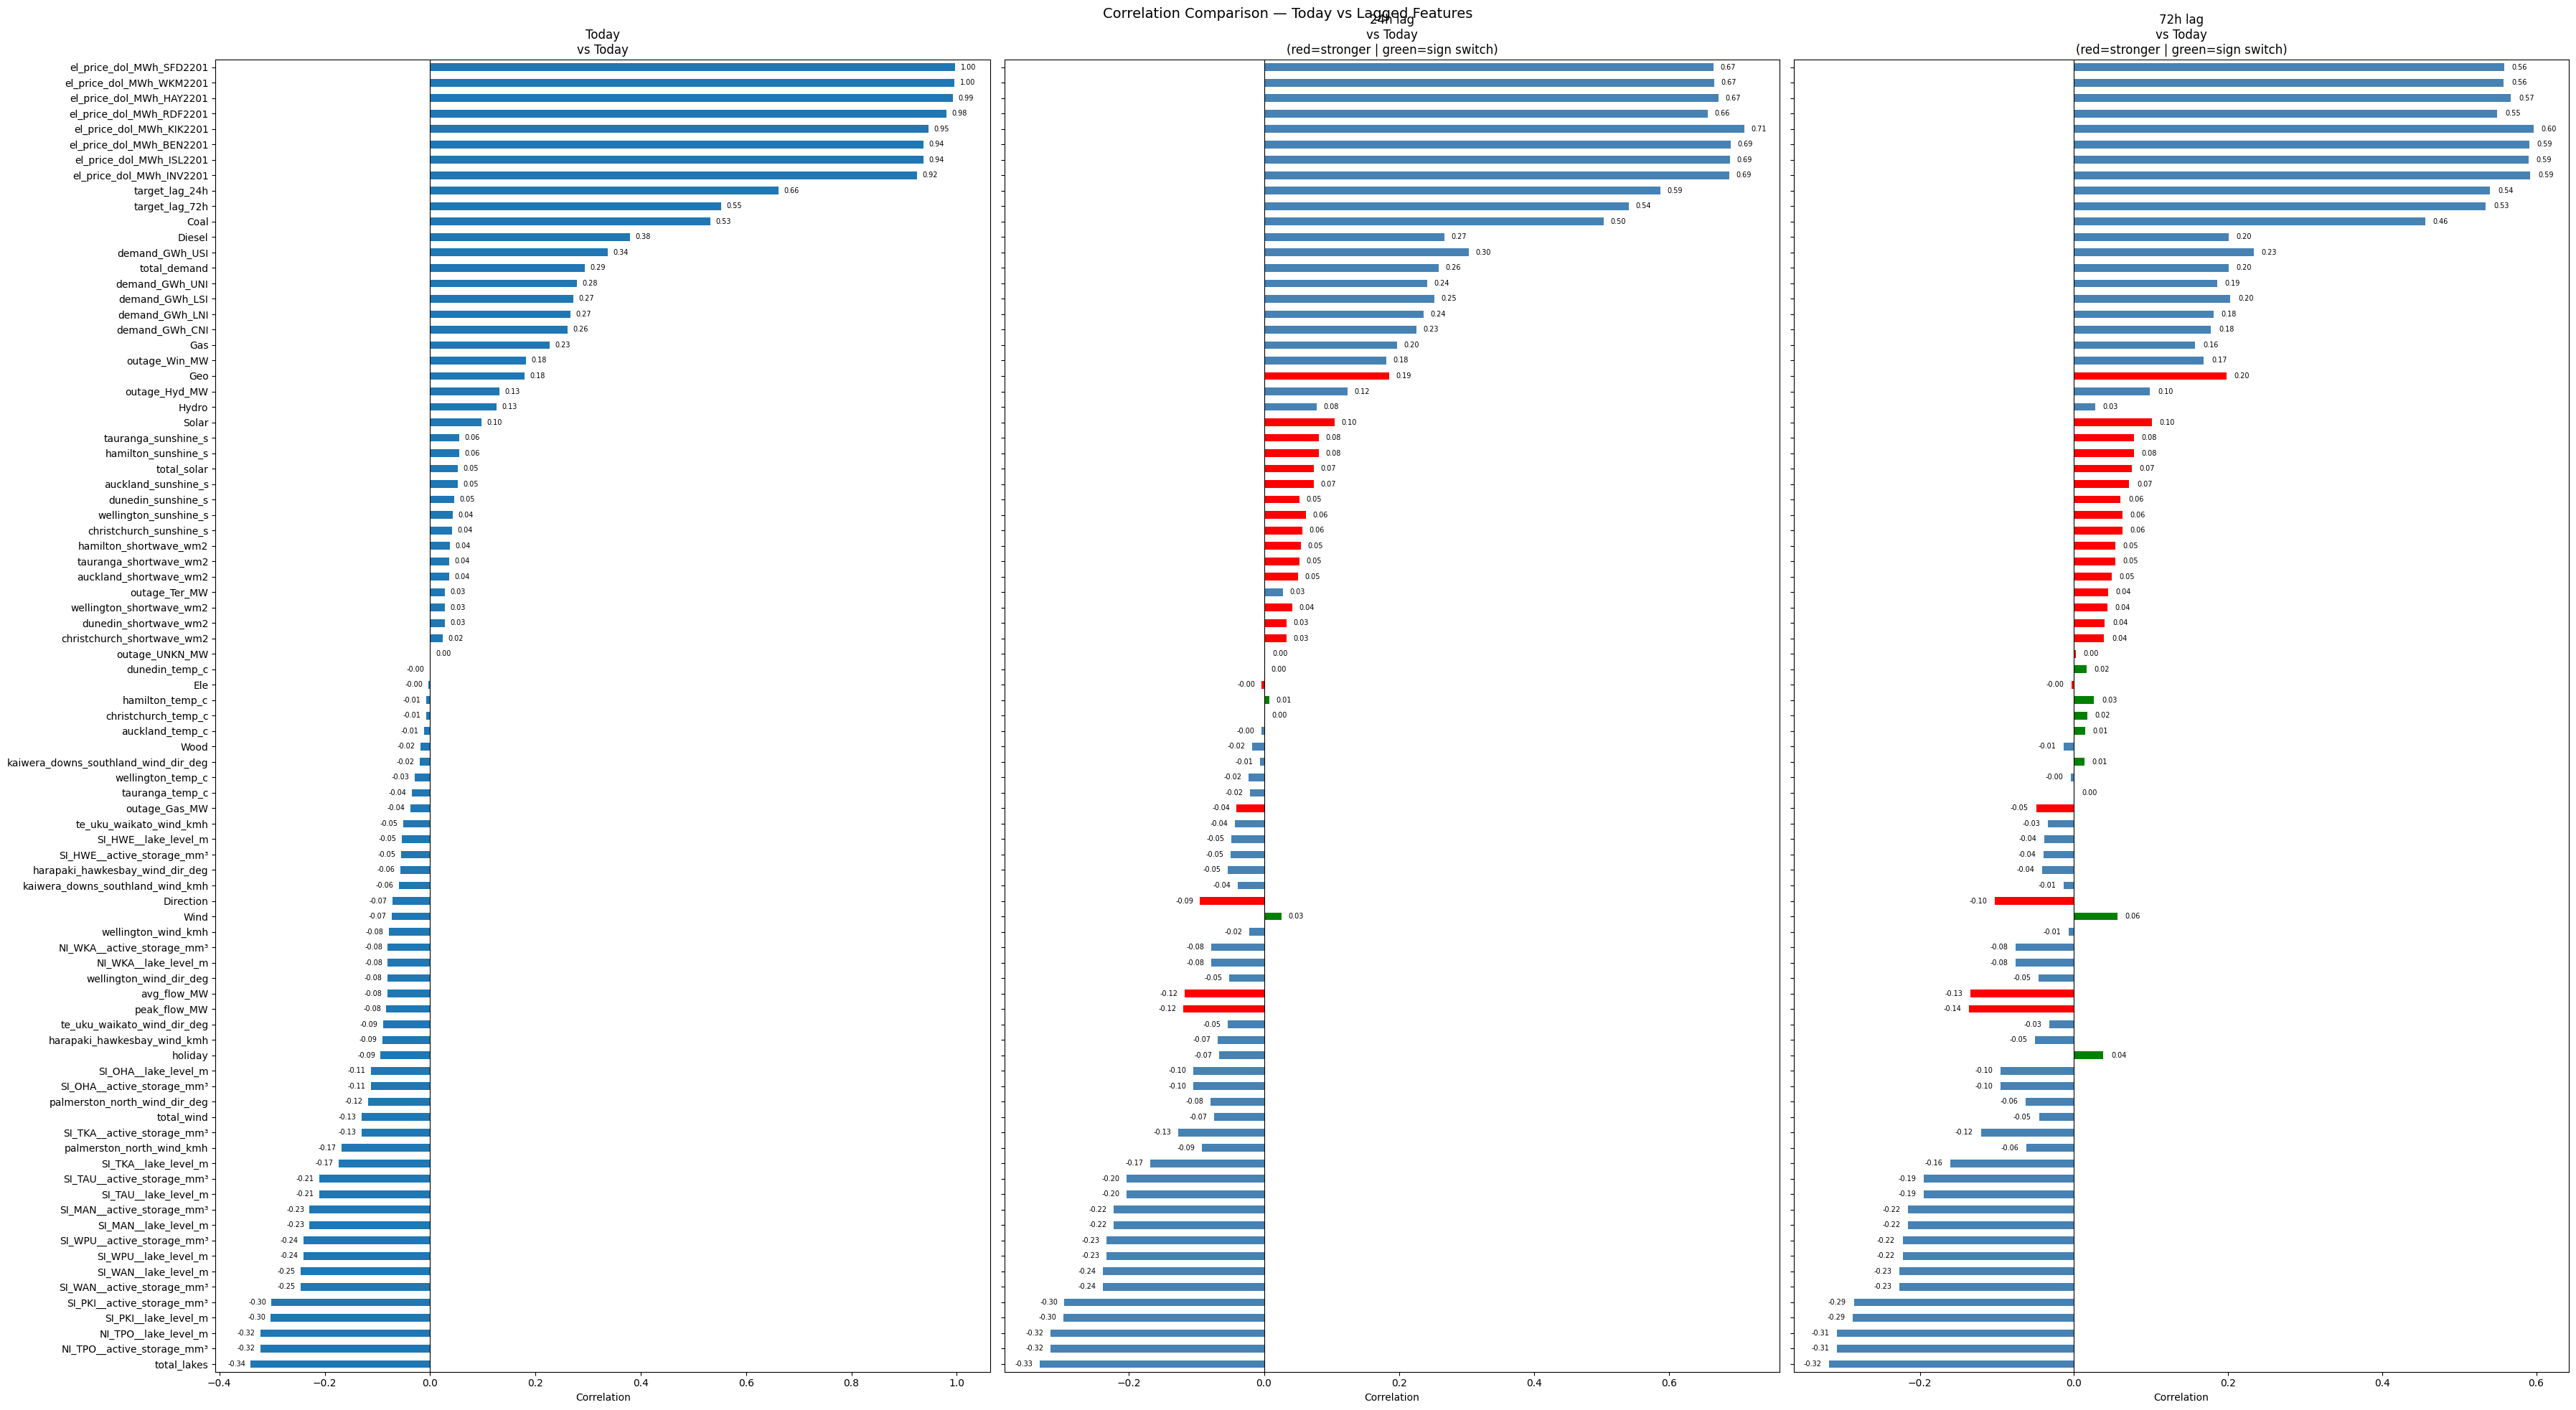

In [34]:
numeric_df = df.select_dtypes(include='number')

# --- Today correlation (anchor for all comparisons) ---
df_today = numeric_df.copy()
df_today[target] = df[target]
corr_today = df_today.corr()[target].drop(target).sort_values()

# --- Lag configs ---
lag_configs = {
    '24h lag':  24,
    '72h lag':  72,
}

# --- Output DataFrames ---
corr_24  = None
corr_72  = None
output_map = {}  # will populate below

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(36, 20), sharey=True)

# Plot Today on first axis
corr_today.plot(kind='barh', ax=axes[0])
for i, value in enumerate(corr_today):
    axes[0].text(
        value + (0.01 if value >= 0 else -0.01),
        i, f'{value:.2f}',
        va='center', ha='left' if value >= 0 else 'right', fontsize=7
    )
axes[0].set_title('Today\nvs Today')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Correlation')

# --- Loop over lags ---
for ax, (lag_label, lag_hours) in zip(axes[1:], lag_configs.items()):

    # Compute lagged correlation
    df_lagged = numeric_df.shift(lag_hours)
    df_lagged[target] = df[target]
    corr_lagged = df_lagged.corr()[target].drop(target)

    # Align to today's order
    corr_lagged_aligned = corr_lagged[corr_today.index]

    # --- Flags ---
    sign_switch  = (corr_today * corr_lagged_aligned) < 0
    abs_improved = (corr_lagged_aligned.abs() > corr_today.abs()) & ~sign_switch

    # --- Colors ---
    colors = []
    for feat in corr_today.index:
        if sign_switch[feat]:
            colors.append('green')
        elif abs_improved[feat]:
            colors.append('red')
        else:
            colors.append('steelblue')

    # --- Plot lag chart ---
    corr_lagged_aligned.plot(kind='barh', ax=ax, color=colors)
    for i, value in enumerate(corr_lagged_aligned):
        ax.text(
            value + (0.01 if value >= 0 else -0.01),
            i, f'{value:.2f}',
            va='center', ha='left' if value >= 0 else 'right', fontsize=7
        )
    ax.set_title(f'{lag_label}\nvs Today\n(red=stronger | green=sign switch)')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Correlation')

    # --- Build summary DataFrame (flagged features only) ---
    flagged = abs_improved | sign_switch

    summary = pd.DataFrame({
        'feature':        corr_today.index[flagged],
        'corr_today':     corr_today[flagged].values,
        f'corr_{lag_hours}h': corr_lagged_aligned[flagged].values,
    }).assign(
        abs_change = lambda x: (x[f'corr_{lag_hours}h'].abs() - x['corr_today'].abs()),
        pct_change = lambda x: ((x[f'corr_{lag_hours}h'].abs() - x['corr_today'].abs()) / x['corr_today'].abs() * 100).round(2),
        flag       = lambda x: x.apply(
            lambda r: 'sign_switch' if (r['corr_today'] * r[f'corr_{lag_hours}h']) < 0 else 'abs_improved', axis=1
        )
    ).sort_values('abs_change', ascending=False).reset_index(drop=True)

    summary = summary[['feature', 'corr_today', f'corr_{lag_hours}h', 'abs_change', 'pct_change', 'flag']]

    output_map[lag_hours] = summary

plt.suptitle('Correlation Comparison — Today vs Lagged Features', fontsize=14)
plt.tight_layout()
plt.show()

# --- Assign to named variables ---
corr_24  = output_map[24]
corr_72  = output_map[72]


# --- All features (flagged + unchanged) ---
for lag_hours in [24, 72]:
    corr_lagged = numeric_df.shift(lag_hours).copy()
    corr_lagged[target] = df[target]
    corr_lagged_aligned = corr_lagged.corr()[target].drop(target)[corr_today.index]

    all_df = pd.DataFrame({
        'feature':            corr_today.index,
        'corr_today':         corr_today.values,
        f'corr_{lag_hours}h': corr_lagged_aligned.values,
    }).assign(
        abs_change = lambda x: (x[f'corr_{lag_hours}h'].abs() - x['corr_today'].abs()),
        pct_change = lambda x: ((x[f'corr_{lag_hours}h'].abs() - x['corr_today'].abs()) / x['corr_today'].abs() * 100).round(2),
        flag       = lambda x: x.apply(
            lambda r: 'sign_switch' if (r['corr_today'] * r[f'corr_{lag_hours}h']) < 0
                      else ('abs_improved' if abs(r[f'corr_{lag_hours}h']) > abs(r['corr_today'])
                      else 'unchanged'), axis=1
        )
    ).sort_values('abs_change', ascending=False).reset_index(drop=True)

    if lag_hours == 24:
        corr_24_all = all_df
    else:
        corr_72_all = all_df


# --- Print summaries ---
# for hours, df_out in [(24, corr_24), (72, corr_72), (168, corr_168), (336, corr_336)]:
#     flagged_count = len(df_out)
#     improved = (df_out['flag'] == 'abs_improved').sum()
#     switched = (df_out['flag'] == 'sign_switch').sum()
#     print(f'\ncorr_{hours}h — {flagged_count} flagged ({improved} stronger, {switched} sign switches):')
#     print(df_out.to_string(index=False))

### 168h & 336h Lagged Correlation

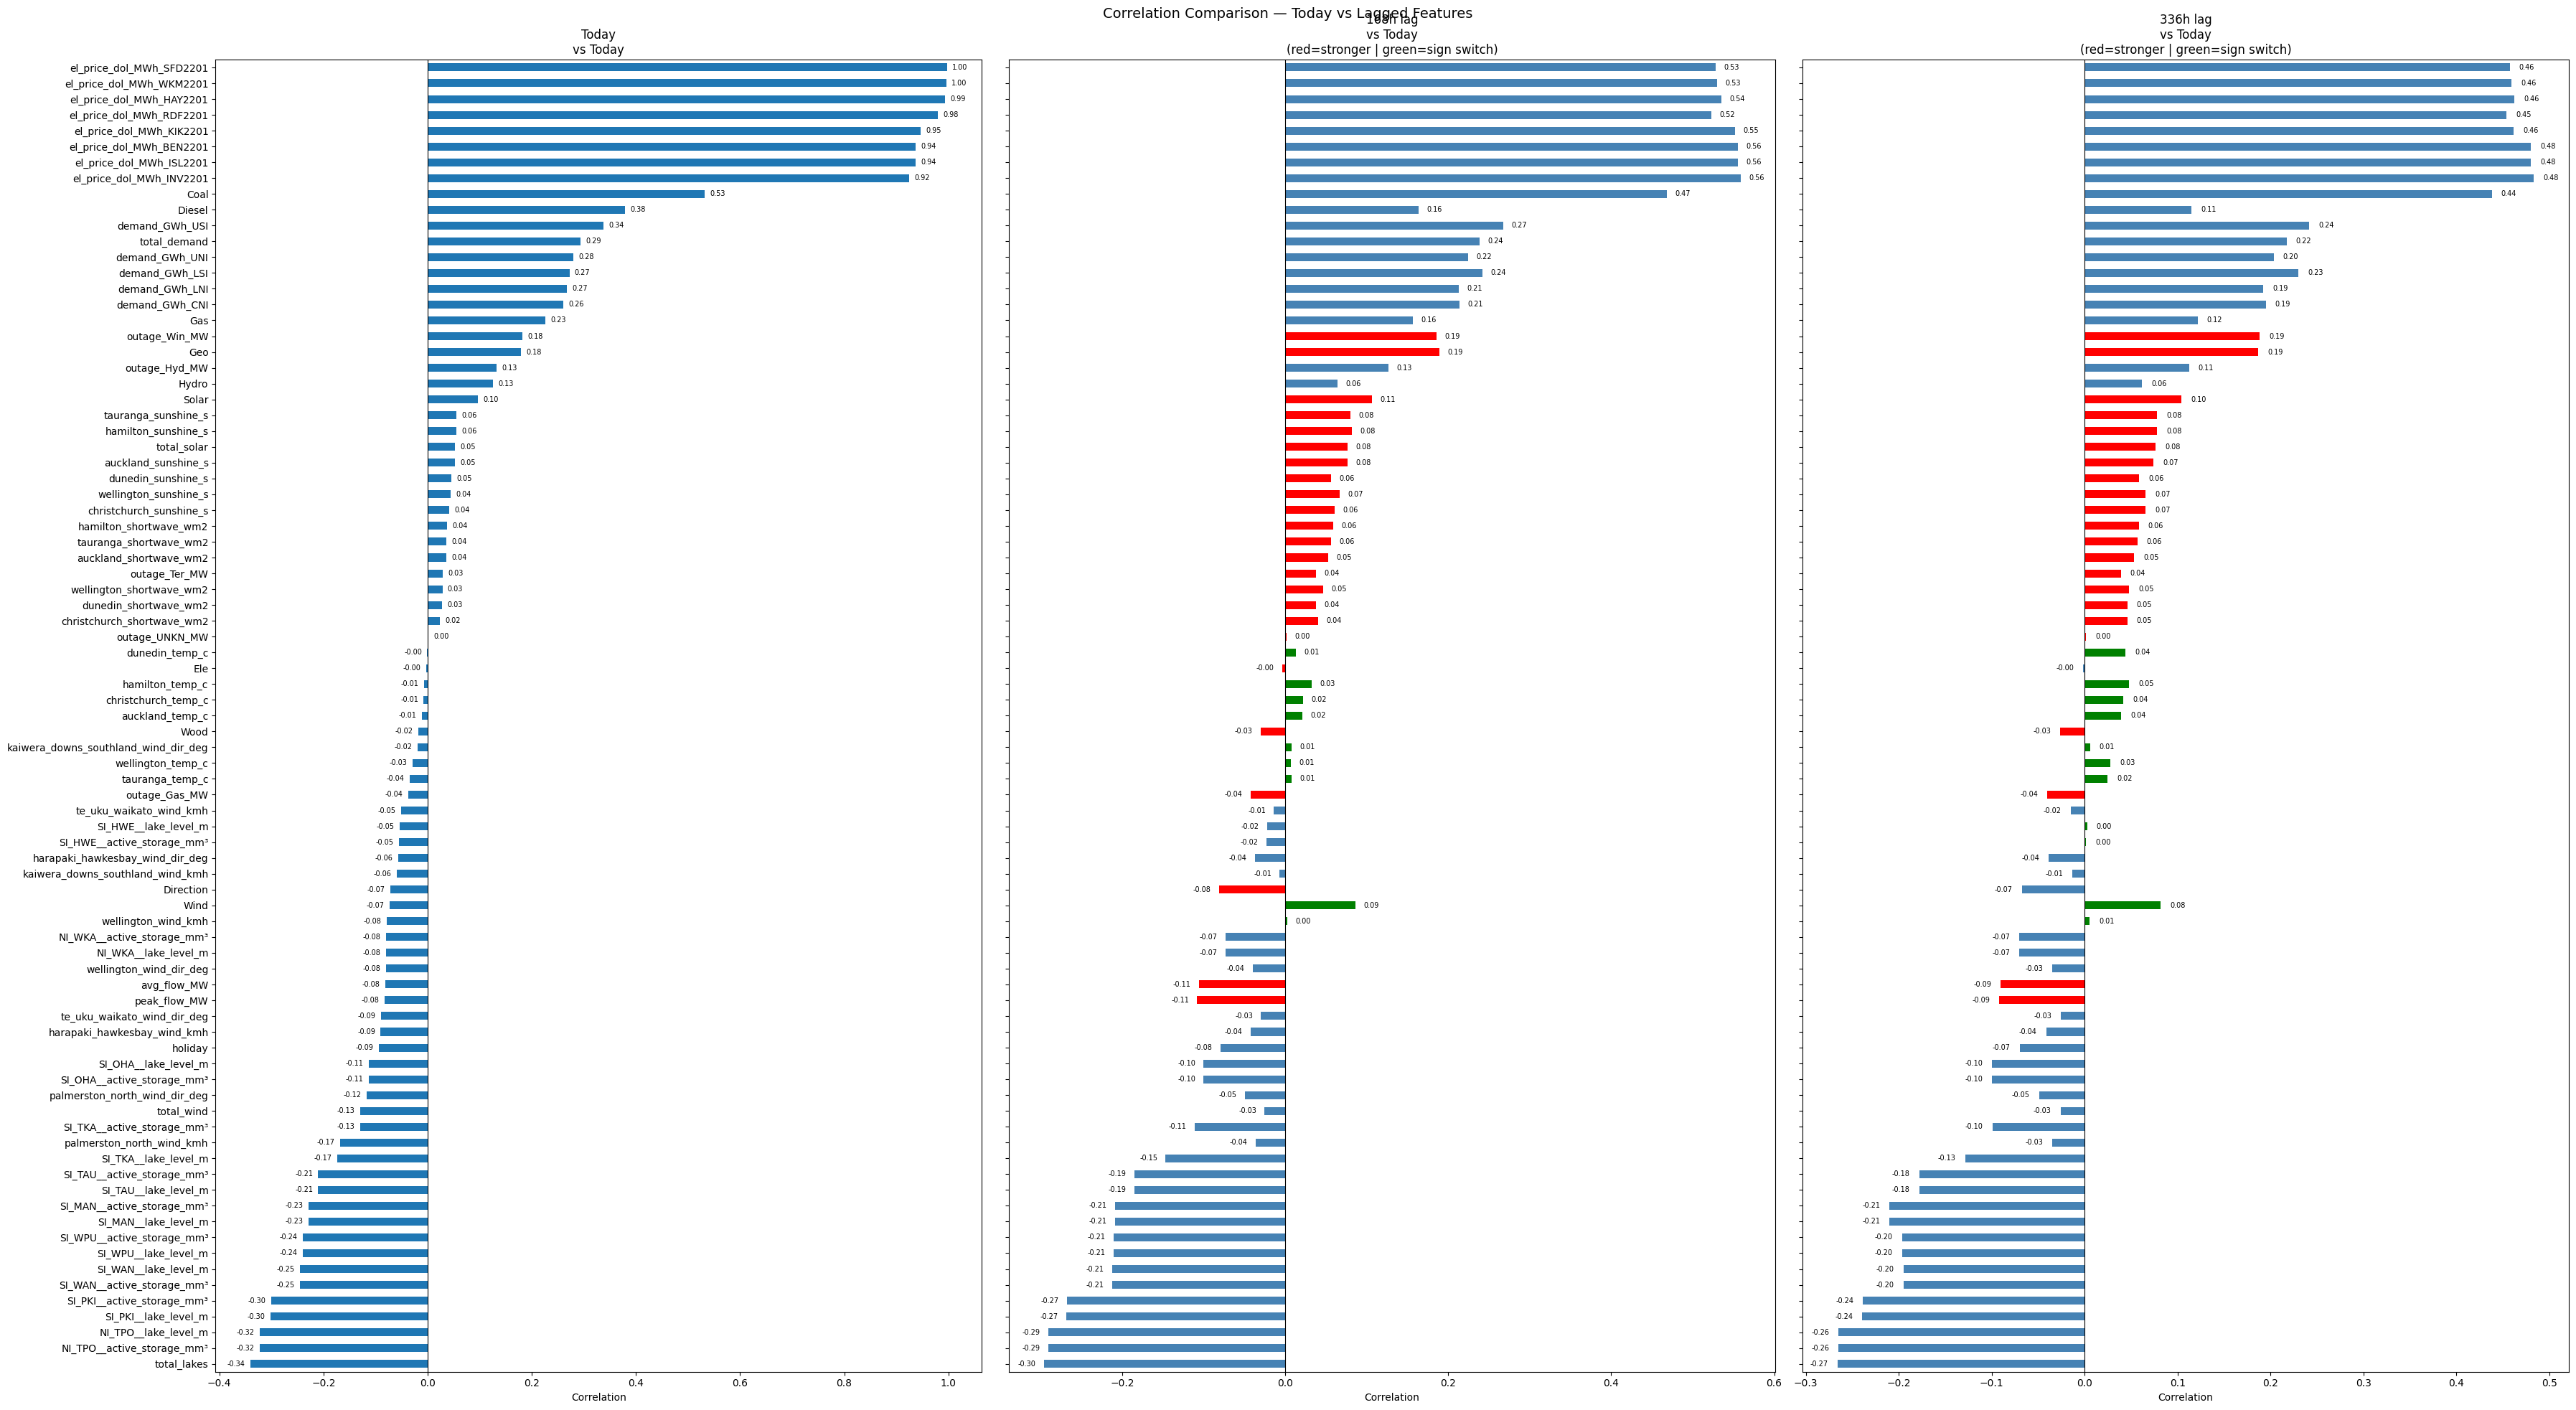

In [22]:

numeric_df = df.select_dtypes(include='number')

# --- Today correlation (anchor for all comparisons) ---
df_today = numeric_df.copy()
df_today[target] = df[target]
corr_today = df_today.corr()[target].drop(target).sort_values()

# --- Lag configs ---
lag_configs = {
    '168h lag': 168,
    '336h lag': 336
}

# --- Output DataFrames ---
corr_168 = None
corr_336 = None
output_map = {}  # will populate below

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(36, 20), sharey=True)

# Plot Today on first axis
corr_today.plot(kind='barh', ax=axes[0])
for i, value in enumerate(corr_today):
    axes[0].text(
        value + (0.01 if value >= 0 else -0.01),
        i, f'{value:.2f}',
        va='center', ha='left' if value >= 0 else 'right', fontsize=7
    )
axes[0].set_title('Today\nvs Today')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Correlation')

# --- Loop over lags ---
for ax, (lag_label, lag_hours) in zip(axes[1:], lag_configs.items()):

    # Compute lagged correlation
    df_lagged = numeric_df.shift(lag_hours)
    df_lagged[target] = df[target]
    corr_lagged = df_lagged.corr()[target].drop(target)

    # Align to today's order
    corr_lagged_aligned = corr_lagged[corr_today.index]

    # --- Flags ---
    sign_switch  = (corr_today * corr_lagged_aligned) < 0
    abs_improved = (corr_lagged_aligned.abs() > corr_today.abs()) & ~sign_switch

    # --- Colors ---
    colors = []
    for feat in corr_today.index:
        if sign_switch[feat]:
            colors.append('green')
        elif abs_improved[feat]:
            colors.append('red')
        else:
            colors.append('steelblue')

    # --- Plot lag chart ---
    corr_lagged_aligned.plot(kind='barh', ax=ax, color=colors)
    for i, value in enumerate(corr_lagged_aligned):
        ax.text(
            value + (0.01 if value >= 0 else -0.01),
            i, f'{value:.2f}',
            va='center', ha='left' if value >= 0 else 'right', fontsize=7
        )
    ax.set_title(f'{lag_label}\nvs Today\n(red=stronger | green=sign switch)')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Correlation')

    # --- Build summary DataFrame (flagged features only) ---
    flagged = abs_improved | sign_switch

    summary = pd.DataFrame({
        'feature':        corr_today.index[flagged],
        'corr_today':     corr_today[flagged].values,
        f'corr_{lag_hours}h': corr_lagged_aligned[flagged].values,
    }).assign(
        abs_change = lambda x: (x[f'corr_{lag_hours}h'].abs() - x['corr_today'].abs()),
        pct_change = lambda x: ((x[f'corr_{lag_hours}h'].abs() - x['corr_today'].abs()) / x['corr_today'].abs() * 100).round(2),
        flag       = lambda x: x.apply(
            lambda r: 'sign_switch' if (r['corr_today'] * r[f'corr_{lag_hours}h']) < 0 else 'abs_improved', axis=1
        )
    ).sort_values('abs_change', ascending=False).reset_index(drop=True)

    summary = summary[['feature', 'corr_today', f'corr_{lag_hours}h', 'abs_change', 'pct_change', 'flag']]

    output_map[lag_hours] = summary

plt.suptitle('Correlation Comparison — Today vs Lagged Features', fontsize=14)
plt.tight_layout()
plt.show()

# --- Assign to named variables ---
corr_168 = output_map[168]
corr_336 = output_map[336]

# --- All features (flagged + unchanged) ---
for lag_hours in [168, 336]:
    corr_lagged = numeric_df.shift(lag_hours).copy()
    corr_lagged[target] = df[target]
    corr_lagged_aligned = corr_lagged.corr()[target].drop(target)[corr_today.index]

    all_df = pd.DataFrame({
        'feature':            corr_today.index,
        'corr_today':         corr_today.values,
        f'corr_{lag_hours}h': corr_lagged_aligned.values,
    }).assign(
        abs_change = lambda x: (x[f'corr_{lag_hours}h'].abs() - x['corr_today'].abs()),
        pct_change = lambda x: ((x[f'corr_{lag_hours}h'].abs() - x['corr_today'].abs()) / x['corr_today'].abs() * 100).round(2),
        flag       = lambda x: x.apply(
            lambda r: 'sign_switch' if (r['corr_today'] * r[f'corr_{lag_hours}h']) < 0
                      else ('abs_improved' if abs(r[f'corr_{lag_hours}h']) > abs(r['corr_today'])
                      else 'unchanged'), axis=1
        )
    ).sort_values('abs_change', ascending=False).reset_index(drop=True)

    if lag_hours == 168:
        corr_168_all = all_df
    else:
        corr_336_all = all_df

# --- Print summaries ---
# for hours, df_out in [(24, corr_24), (72, corr_72), (168, corr_168), (336, corr_336)]:
#     flagged_count = len(df_out)
#     improved = (df_out['flag'] == 'abs_improved').sum()
#     switched = (df_out['flag'] == 'sign_switch').sum()
#     print(f'\ncorr_{hours}h — {flagged_count} flagged ({improved} stronger, {switched} sign switches):')
#     print(df_out.to_string(index=False))

### 7 Day Moving Average Lagged Correlation

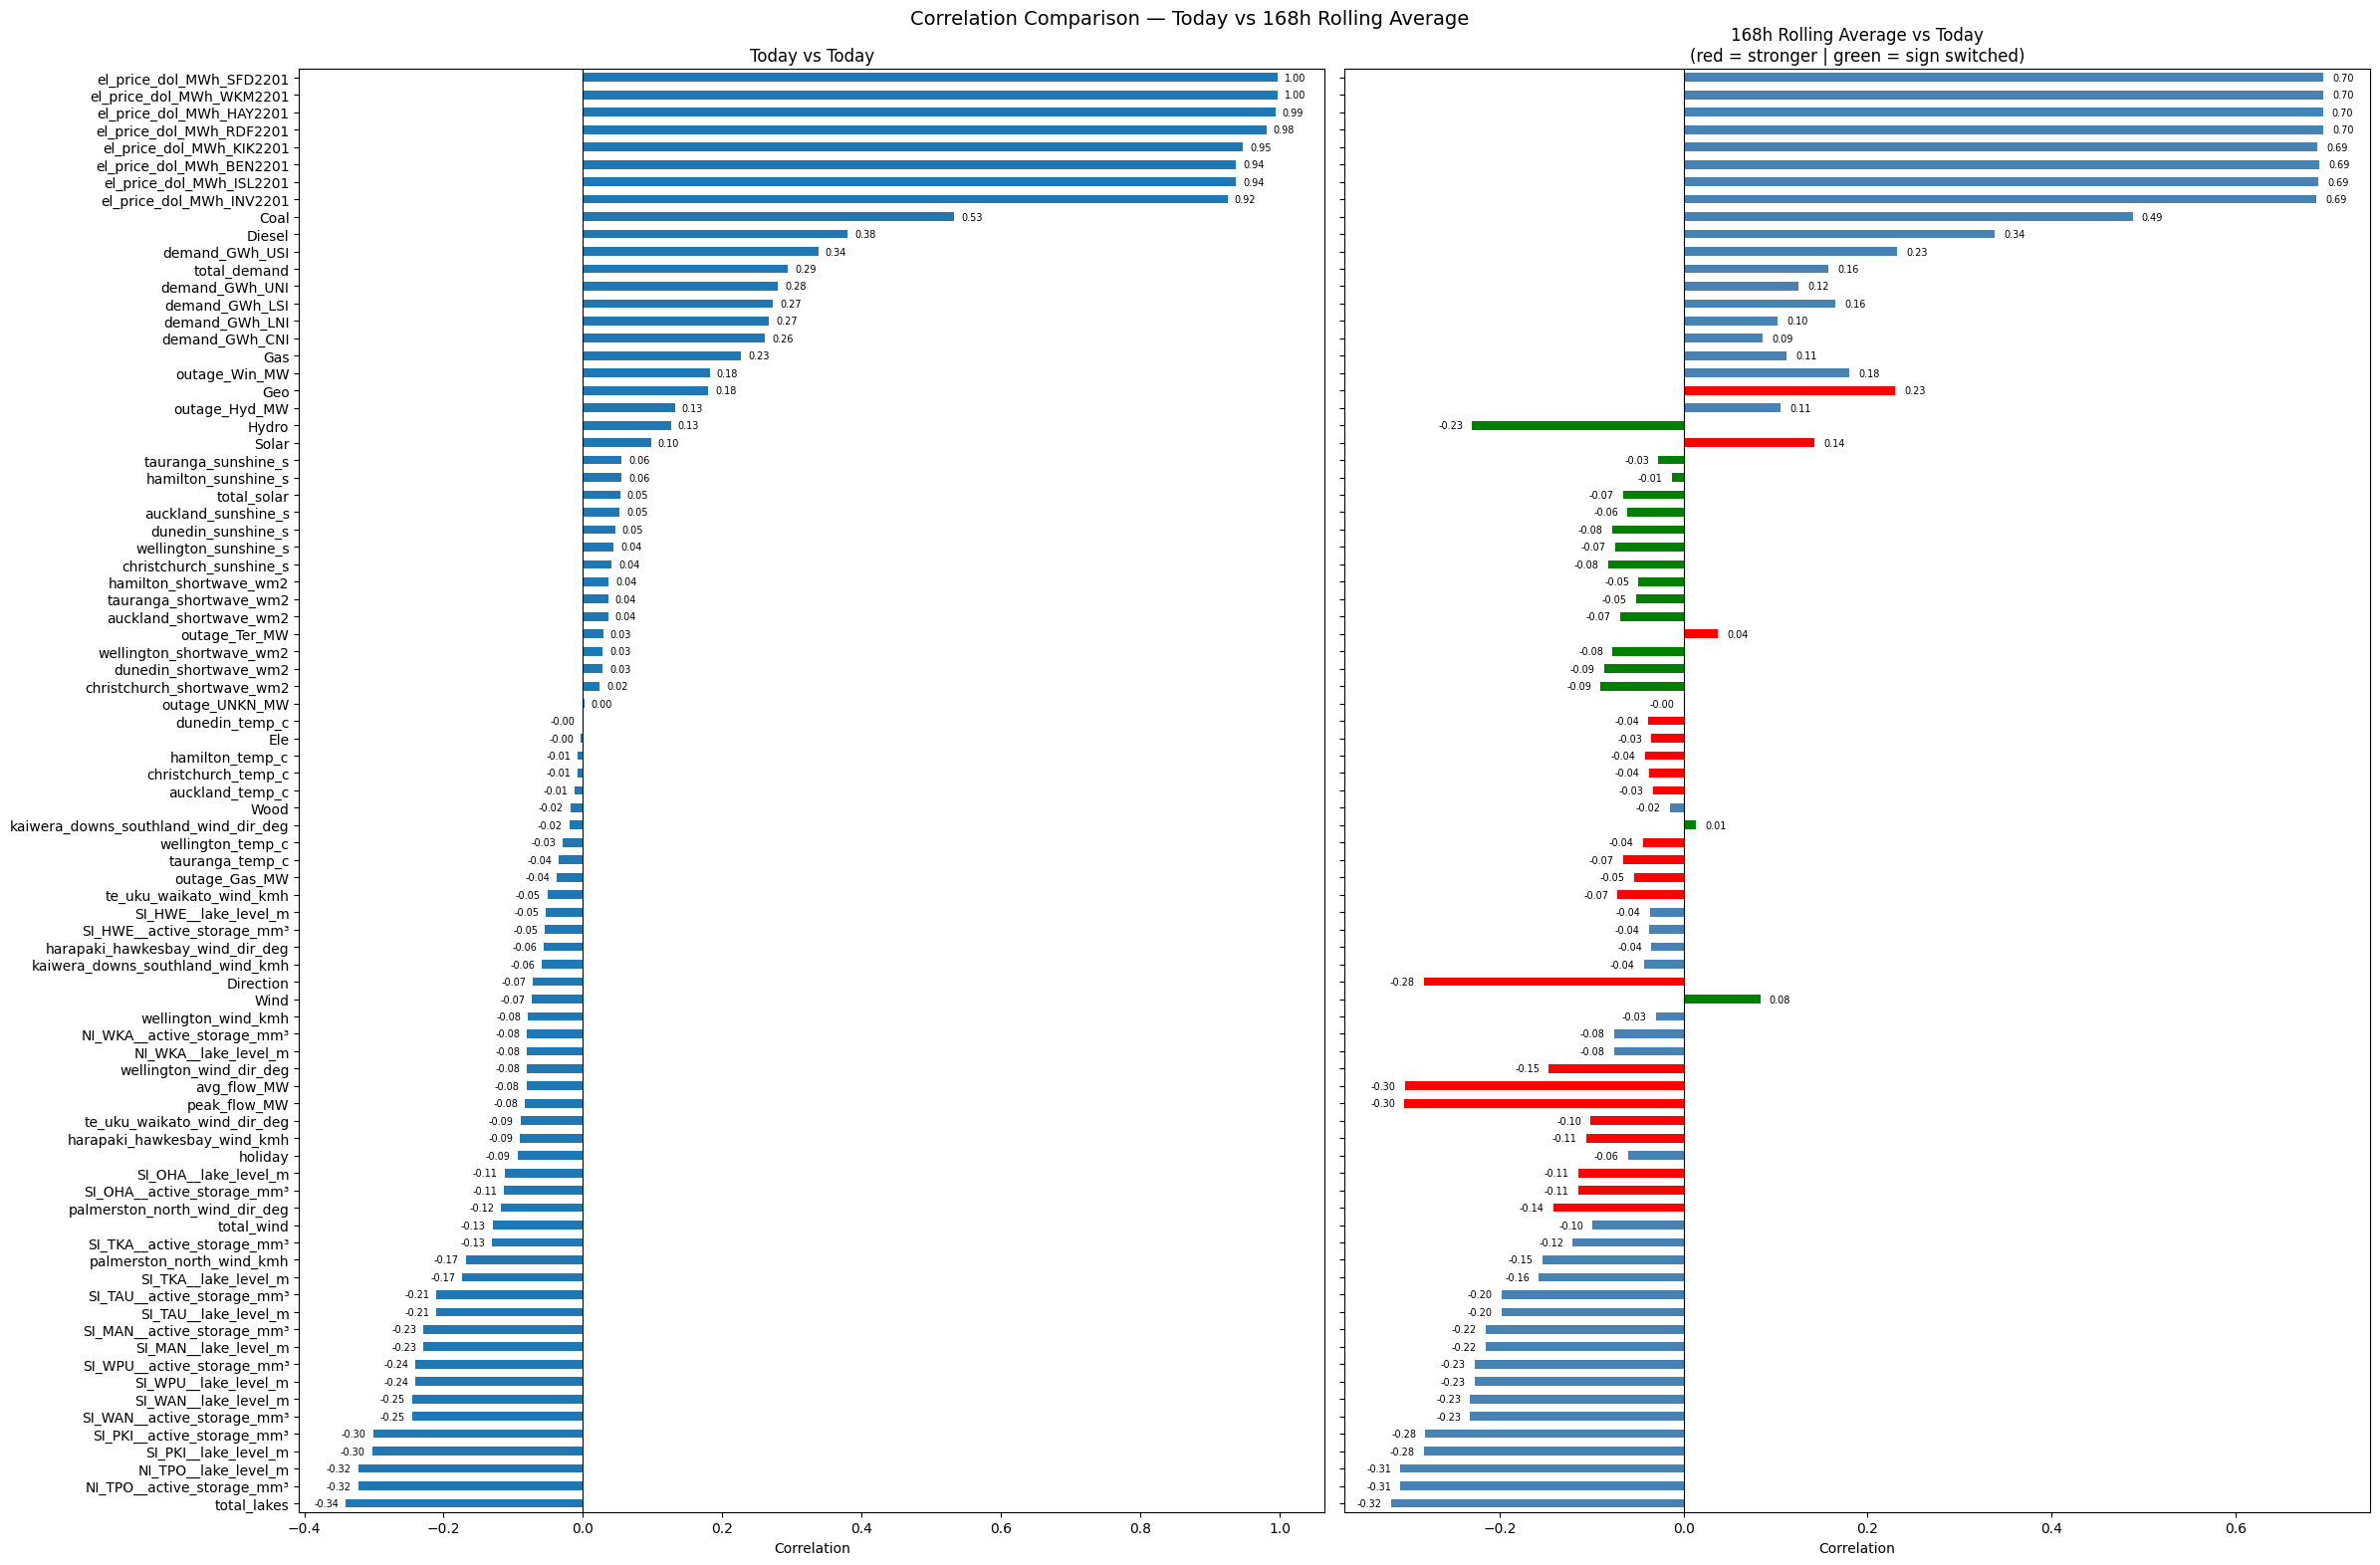

In [23]:

numeric_df = df.select_dtypes(include='number')

# --- Compute both correlations ---
df_today = numeric_df.copy()
df_today[target] = df[target]
corr_today = df_today.corr()[target].drop(target).sort_values()

df_rolling = numeric_df.shift(1).rolling(window=168).mean()
df_rolling[target] = df[target]
corr_rolling = df_rolling.corr()[target].drop(target)

# Align rolling to today's order
corr_rolling_aligned = corr_rolling[corr_today.index]

# --- Flags ---
sign_switch  = (corr_today * corr_rolling_aligned) < 0                        # green: sign flipped
abs_improved = (corr_rolling_aligned.abs() > corr_today.abs()) & ~sign_switch  # red: stronger, same sign

# --- Colors ---
colors = []
for feat in corr_today.index:
    if sign_switch[feat]:
        colors.append('green')
    elif abs_improved[feat]:
        colors.append('red')
    else:
        colors.append('steelblue')

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(24, 16), sharey=True)

# Today chart
corr_today.plot(kind='barh', ax=axes[0])
for i, value in enumerate(corr_today):
    axes[0].text(
        value + (0.01 if value >= 0 else -0.01),
        i, f'{value:.2f}',
        va='center', ha='left' if value >= 0 else 'right', fontsize=7
    )
axes[0].set_title('Today vs Today')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Correlation')

# Rolling chart
corr_rolling_aligned.plot(kind='barh', ax=axes[1], color=colors)
for i, value in enumerate(corr_rolling_aligned):
    axes[1].text(
        value + (0.01 if value >= 0 else -0.01),
        i, f'{value:.2f}',
        va='center', ha='left' if value >= 0 else 'right', fontsize=7
    )
axes[1].set_title('168h Rolling Average vs Today\n(red = stronger | green = sign switched)')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Correlation')

plt.suptitle('Correlation Comparison — Today vs 168h Rolling Average', fontsize=14)
plt.tight_layout()
plt.show()

# --- Summary DataFrame (red + green features) ---
flagged = abs_improved | sign_switch

summary = pd.DataFrame({
    'feature':          corr_today.index[flagged],
    'corr_today':       corr_today[flagged].values,
    'corr_rolling_168': corr_rolling_aligned[flagged].values,
}).assign(
    abs_change = lambda x: (x['corr_rolling_168'].abs() - x['corr_today'].abs()),
    pct_change = lambda x: ((x['corr_rolling_168'].abs() - x['corr_today'].abs()) / x['corr_today'].abs() * 100).round(2),
    flag       = lambda x: x.apply(
        lambda r: 'sign_switch' if (r['corr_today'] * r['corr_rolling_168']) < 0 else 'abs_improved', axis=1
    )
).sort_values('abs_change', ascending=False).reset_index(drop=True)

# Reorder columns
summary = summary[['feature', 'corr_today', 'corr_rolling_168', 'abs_change', 'pct_change', 'flag']]
corr_rolling_168 = summary

# Get all correlations
corr_rolling_168_all = pd.DataFrame({
    'feature':          corr_today.index,
    'corr_today':       corr_today.values,
    'corr_rolling_168': corr_rolling_aligned.values,
}).assign(
    abs_change = lambda x: (x['corr_rolling_168'].abs() - x['corr_today'].abs()),
    pct_change = lambda x: ((x['corr_rolling_168'].abs() - x['corr_today'].abs()) / x['corr_today'].abs() * 100).round(2),
    flag       = lambda x: x.apply(
        lambda r: 'sign_switch' if (r['corr_today'] * r['corr_rolling_168']) < 0
                  else ('abs_improved' if abs(r['corr_rolling_168']) > abs(r['corr_today'])
                  else 'unchanged'), axis=1
    )
).sort_values('abs_change', ascending=False).reset_index(drop=True)

# print(f'{len(summary)} features flagged ({abs_improved.sum()} stronger, {sign_switch.sum()} sign switches):\n')
# print(summary.to_string(index=False))

### 3 Day Moving Average Lagged Correlation

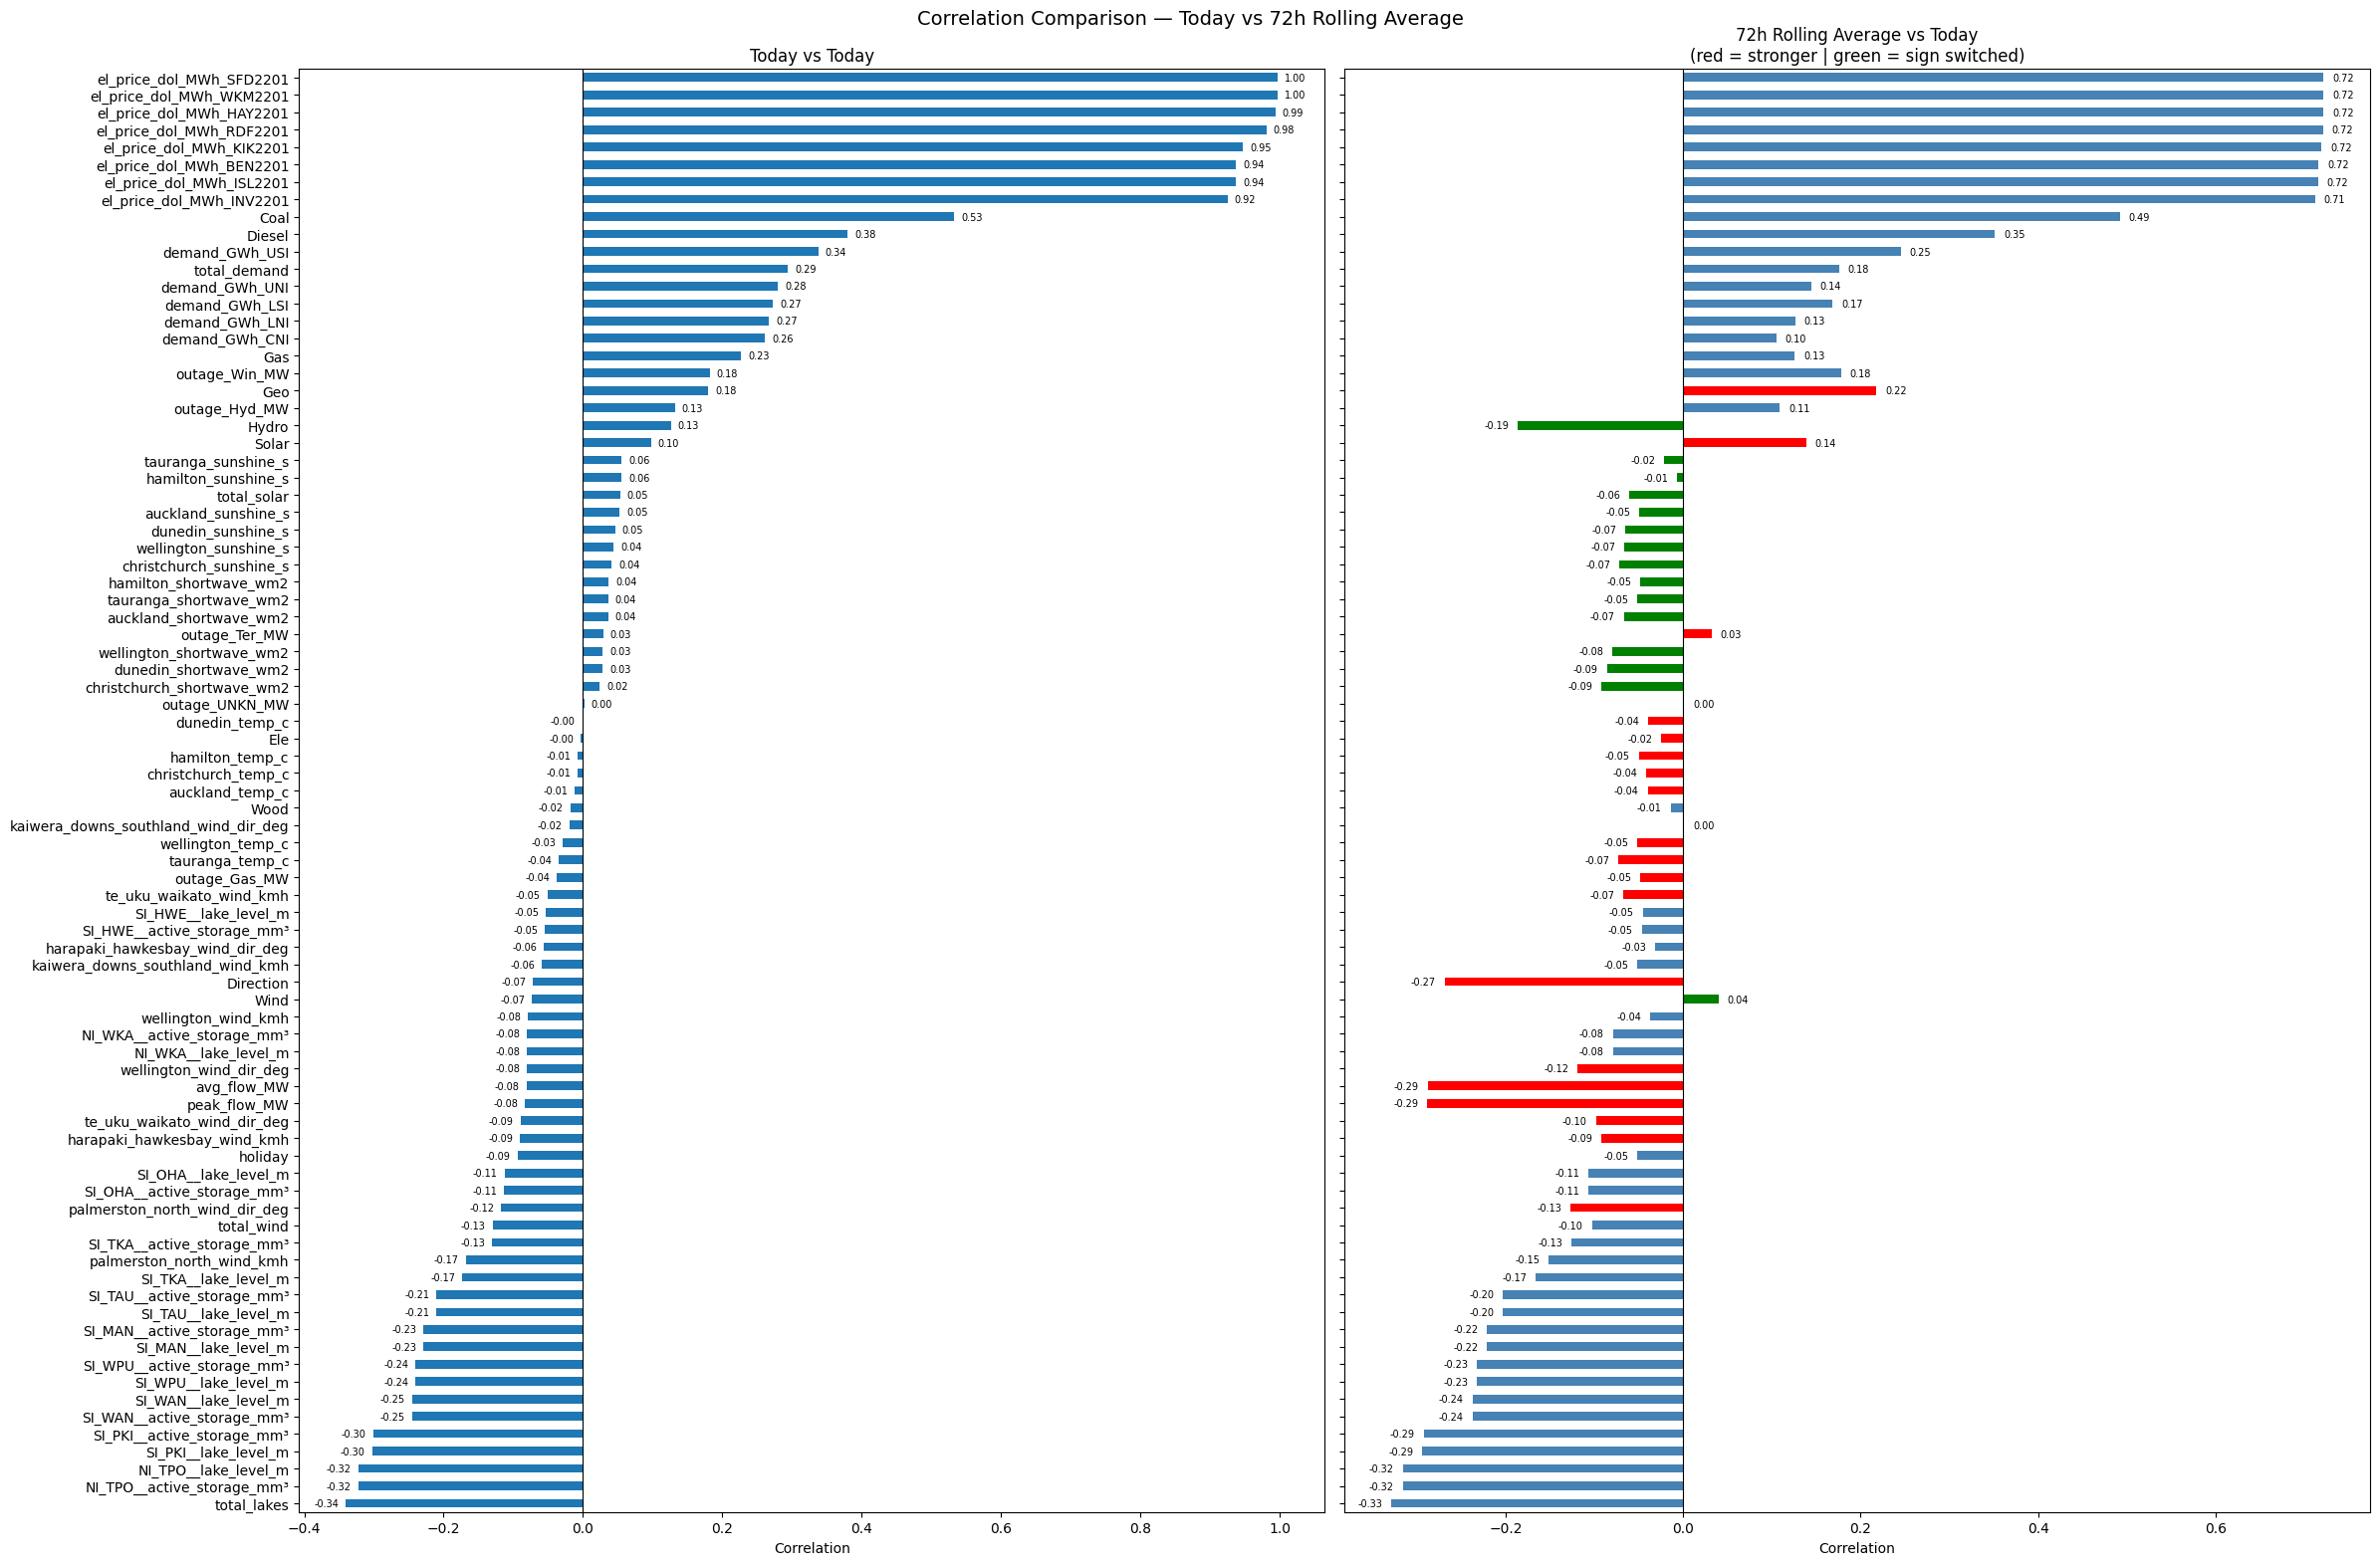

In [30]:
numeric_df = df.select_dtypes(include='number')

# --- Compute both correlations ---
df_today = numeric_df.copy()
df_today[target] = df[target]
corr_today = df_today.corr()[target].drop(target).sort_values()

df_rolling = numeric_df.shift(1).rolling(window=72).mean()
df_rolling[target] = df[target]
corr_rolling = df_rolling.corr()[target].drop(target)

# Align rolling to today's order
corr_rolling_aligned = corr_rolling[corr_today.index]

# --- Flags ---
sign_switch  = (corr_today * corr_rolling_aligned) < 0
abs_improved = (corr_rolling_aligned.abs() > corr_today.abs()) & ~sign_switch

# --- Colors ---
colors = []
for feat in corr_today.index:
    if sign_switch[feat]:
        colors.append('green')
    elif abs_improved[feat]:
        colors.append('red')
    else:
        colors.append('steelblue')

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(24, 16), sharey=True)

corr_today.plot(kind='barh', ax=axes[0])
for i, value in enumerate(corr_today):
    axes[0].text(
        value + (0.01 if value >= 0 else -0.01),
        i, f'{value:.2f}',
        va='center', ha='left' if value >= 0 else 'right', fontsize=7
    )
axes[0].set_title('Today vs Today')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Correlation')

corr_rolling_aligned.plot(kind='barh', ax=axes[1], color=colors)
for i, value in enumerate(corr_rolling_aligned):
    axes[1].text(
        value + (0.01 if value >= 0 else -0.01),
        i, f'{value:.2f}',
        va='center', ha='left' if value >= 0 else 'right', fontsize=7
    )
axes[1].set_title('72h Rolling Average vs Today\n(red = stronger | green = sign switched)')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Correlation')

plt.suptitle('Correlation Comparison — Today vs 72h Rolling Average', fontsize=14)
plt.tight_layout()
plt.show()

# --- Summary DataFrame (red + green features) ---
flagged = abs_improved | sign_switch

summary = pd.DataFrame({
    'feature':         corr_today.index[flagged],
    'corr_today':      corr_today[flagged].values,
    'corr_rolling_72': corr_rolling_aligned[flagged].values,
}).assign(
    abs_change = lambda x: (x['corr_rolling_72'].abs() - x['corr_today'].abs()),
    pct_change = lambda x: ((x['corr_rolling_72'].abs() - x['corr_today'].abs()) / x['corr_today'].abs() * 100).round(2),
    flag       = lambda x: x.apply(
        lambda r: 'sign_switch' if (r['corr_today'] * r['corr_rolling_72']) < 0 else 'abs_improved', axis=1
    )
).sort_values('abs_change', ascending=False).reset_index(drop=True)

summary = summary[['feature', 'corr_today', 'corr_rolling_72', 'abs_change', 'pct_change', 'flag']]
corr_rolling_72 = summary

# --- All features ---
corr_rolling_72_all = pd.DataFrame({
    'feature':         corr_today.index,
    'corr_today':      corr_today.values,
    'corr_rolling_72': corr_rolling_aligned.values,
}).assign(
    abs_change = lambda x: (x['corr_rolling_72'].abs() - x['corr_today'].abs()),
    pct_change = lambda x: ((x['corr_rolling_72'].abs() - x['corr_today'].abs()) / x['corr_today'].abs() * 100).round(2),
    flag       = lambda x: x.apply(
        lambda r: 'sign_switch' if (r['corr_today'] * r['corr_rolling_72']) < 0
                  else ('abs_improved' if abs(r['corr_rolling_72']) > abs(r['corr_today'])
                  else 'unchanged'), axis=1
    )
).sort_values('abs_change', ascending=False).reset_index(drop=True)

All df correlations:
- corr_24_all
- corr_72_all
- corr_168_all
- corr_336_all
- corr_rolling_168_all

In [24]:
print(corr_24_all.shape)
print(corr_72_all.shape)
print(corr_168_all.shape)
print(corr_336_all.shape)
print(corr_rolling_168_all.shape)

(83, 6)
(83, 6)
(83, 6)
(83, 6)
(83, 6)


In [25]:
print(corr_24_all.columns.tolist())
print(corr_72_all.columns.tolist())
print(corr_168_all.columns.tolist())
print(corr_336_all.columns.tolist())
print(corr_rolling_168_all.columns.tolist())

['feature', 'corr_today', 'corr_24h', 'abs_change', 'pct_change', 'flag']
['feature', 'corr_today', 'corr_72h', 'abs_change', 'pct_change', 'flag']
['feature', 'corr_today', 'corr_168h', 'abs_change', 'pct_change', 'flag']
['feature', 'corr_today', 'corr_336h', 'abs_change', 'pct_change', 'flag']
['feature', 'corr_today', 'corr_rolling_168', 'abs_change', 'pct_change', 'flag']


### Correlation Comparions Including Today (Do not use since the today correlation is data leakage unless we assume at the time of prediction we'll have forecasts for those features, like weather)

In [26]:
cutoff = 0.20

all_corr_dfs = {
    'corr_24h':         (corr_24_all,          'corr_24h'),
    'corr_72h':         (corr_72_all,          'corr_72h'),
    'corr_168h':        (corr_168_all,         'corr_168h'),
    'corr_336h':        (corr_336_all,         'corr_336h'),
    'corr_rolling_168': (corr_rolling_168_all, 'corr_rolling_168'),
}

feature_best = {}

for lag_name, (df_corr, lag_col) in all_corr_dfs.items():
    for _, row in df_corr.iterrows():
        feat           = row['feature']
        corr_today_val = row['corr_today']
        corr_lag_val   = row[lag_col]

        # Best lag: highest abs correlation among all lags (excluding today)
        if feat not in feature_best:
            feature_best[feat] = {
                'corr_today':    corr_today_val,
                'best_lag':      lag_name,
                'best_lag_corr': corr_lag_val,
            }
        else:
            # Update best lag if this lag is stronger
            if abs(corr_lag_val) > abs(feature_best[feat]['best_lag_corr']):
                feature_best[feat]['best_lag']      = lag_name
                feature_best[feat]['best_lag_corr'] = corr_lag_val

# --- Apply cutoff and determine best source ---
rows = []
for feat, vals in feature_best.items():
    corr_today    = vals['corr_today']
    best_lag_corr = vals['best_lag_corr']

    # Best overall: today or best lag?
    if abs(corr_today) >= abs(best_lag_corr):
        best_source = 'today'
        best_corr   = corr_today
    else:
        best_source = vals['best_lag']
        best_corr   = best_lag_corr

    # Apply cutoff on best corr
    if abs(best_corr) < cutoff:
        continue

    rows.append({
        'feature':       feat,
        'corr_today':    corr_today,
        'best_lag':      vals['best_lag'],
        'best_lag_corr': best_lag_corr,
        'best_source':   best_source,
        'best_corr':     best_corr,
    })

# --- Build DataFrame ---
feature_selection_df = (
    pd.DataFrame(rows)
    .sort_values('best_corr', key=abs, ascending=False)
    .reset_index(drop=True)
)

# --- Build dictionary ---
feature_selection_dict = {
    row['feature']: row.drop('feature').to_dict()
    for _, row in feature_selection_df.iterrows()
}

print(f'Features passing cutoff (|corr| >= {cutoff}): {len(feature_selection_df)}')
print(f'Features dropped: {len(corr_24_all) - len(feature_selection_df)}')
print()
feature_selection_df

Features passing cutoff (|corr| >= 0.2): 35
Features dropped: 48



,feature,corr_today,best_lag,best_lag_corr,best_source,best_corr
0,el_price_dol_MWh_SFD2201,0.997094,corr_rolling_168,0.695758,today,0.997094
1,el_price_dol_MWh_WKM2201,0.995980,corr_rolling_168,0.695938,today,0.995980
2,el_price_dol_MWh_HAY2201,0.993048,corr_rolling_168,0.695274,today,0.993048
3,el_price_dol_MWh_RDF2201,0.980406,corr_rolling_168,0.695479,today,0.980406
4,el_price_dol_MWh_KIK2201,0.946741,corr_24h,0.711541,today,0.946741
5,el_price_dol_MWh_BEN2201,0.937026,corr_rolling_168,0.691052,today,0.937026
6,el_price_dol_MWh_ISL2201,0.936946,corr_rolling_168,0.690745,today,0.936946
7,el_price_dol_MWh_INV2201,0.924425,corr_24h,0.689184,today,0.924425
8,Coal,0.532546,corr_24h,0.502964,today,0.532546
9,Diesel,0.379445,corr_rolling_168,0.338182,today,0.379445


### Correlation Comparions - Lagged Only (avoids data leakage)

In [31]:
cutoff = 0.20

all_corr_dfs = {
    'corr_24h':         (corr_24_all,          'corr_24h'),
    'corr_72h':         (corr_72_all,          'corr_72h'),
    'corr_168h':        (corr_168_all,         'corr_168h'),
    'corr_336h':        (corr_336_all,         'corr_336h'),
    'corr_rolling_72': (corr_rolling_72_all, 'corr_rolling_72'),
    'corr_rolling_168': (corr_rolling_168_all, 'corr_rolling_168'),
}

feature_best = {}

for lag_name, (df_corr, lag_col) in all_corr_dfs.items():
    for _, row in df_corr.iterrows():
        feat         = row['feature']
        corr_lag_val = row[lag_col]

        # Best lag: highest abs correlation across all lags (today excluded entirely)
        if feat not in feature_best:
            feature_best[feat] = {
                'best_lag':      lag_name,
                'best_lag_corr': corr_lag_val,
            }
        else:
            if abs(corr_lag_val) > abs(feature_best[feat]['best_lag_corr']):
                feature_best[feat]['best_lag']      = lag_name
                feature_best[feat]['best_lag_corr'] = corr_lag_val

# --- Apply cutoff ---
rows = []
for feat, vals in feature_best.items():
    best_lag_corr = vals['best_lag_corr']

    if abs(best_lag_corr) < cutoff:
        continue

    rows.append({
        'feature':       feat,
        'best_lag':      vals['best_lag'],
        'best_lag_corr': best_lag_corr,
    })

# --- Build DataFrame ---
feature_selection_df = (
    pd.DataFrame(rows)
    .sort_values('best_lag_corr', key=abs, ascending=False)
    .reset_index(drop=True)
)

# --- Build dictionary ---
feature_selection_dict = {
    row['feature']: row.drop('feature').to_dict()
    for _, row in feature_selection_df.iterrows()
}

print(f'Features passing cutoff (|corr| >= {cutoff}): {len(feature_selection_df)}')
print(f'Features dropped: {len(corr_24_all) - len(feature_selection_df)}')
print()
feature_selection_df

Features passing cutoff (|corr| >= 0.2): 34
Features dropped: 49



,feature,best_lag,best_lag_corr
0,el_price_dol_MWh_WKM2201,corr_rolling_72,0.721639
1,el_price_dol_MWh_SFD2201,corr_rolling_72,0.721562
2,el_price_dol_MWh_HAY2201,corr_rolling_72,0.721489
3,el_price_dol_MWh_RDF2201,corr_rolling_72,0.720998
4,el_price_dol_MWh_KIK2201,corr_rolling_72,0.719166
5,el_price_dol_MWh_BEN2201,corr_rolling_72,0.715838
6,el_price_dol_MWh_ISL2201,corr_rolling_72,0.715468
7,el_price_dol_MWh_INV2201,corr_rolling_72,0.712097
8,Coal,corr_24h,0.502964
9,Diesel,corr_rolling_72,0.351319


## 2. Feature vs Target Correlation - Heatmap

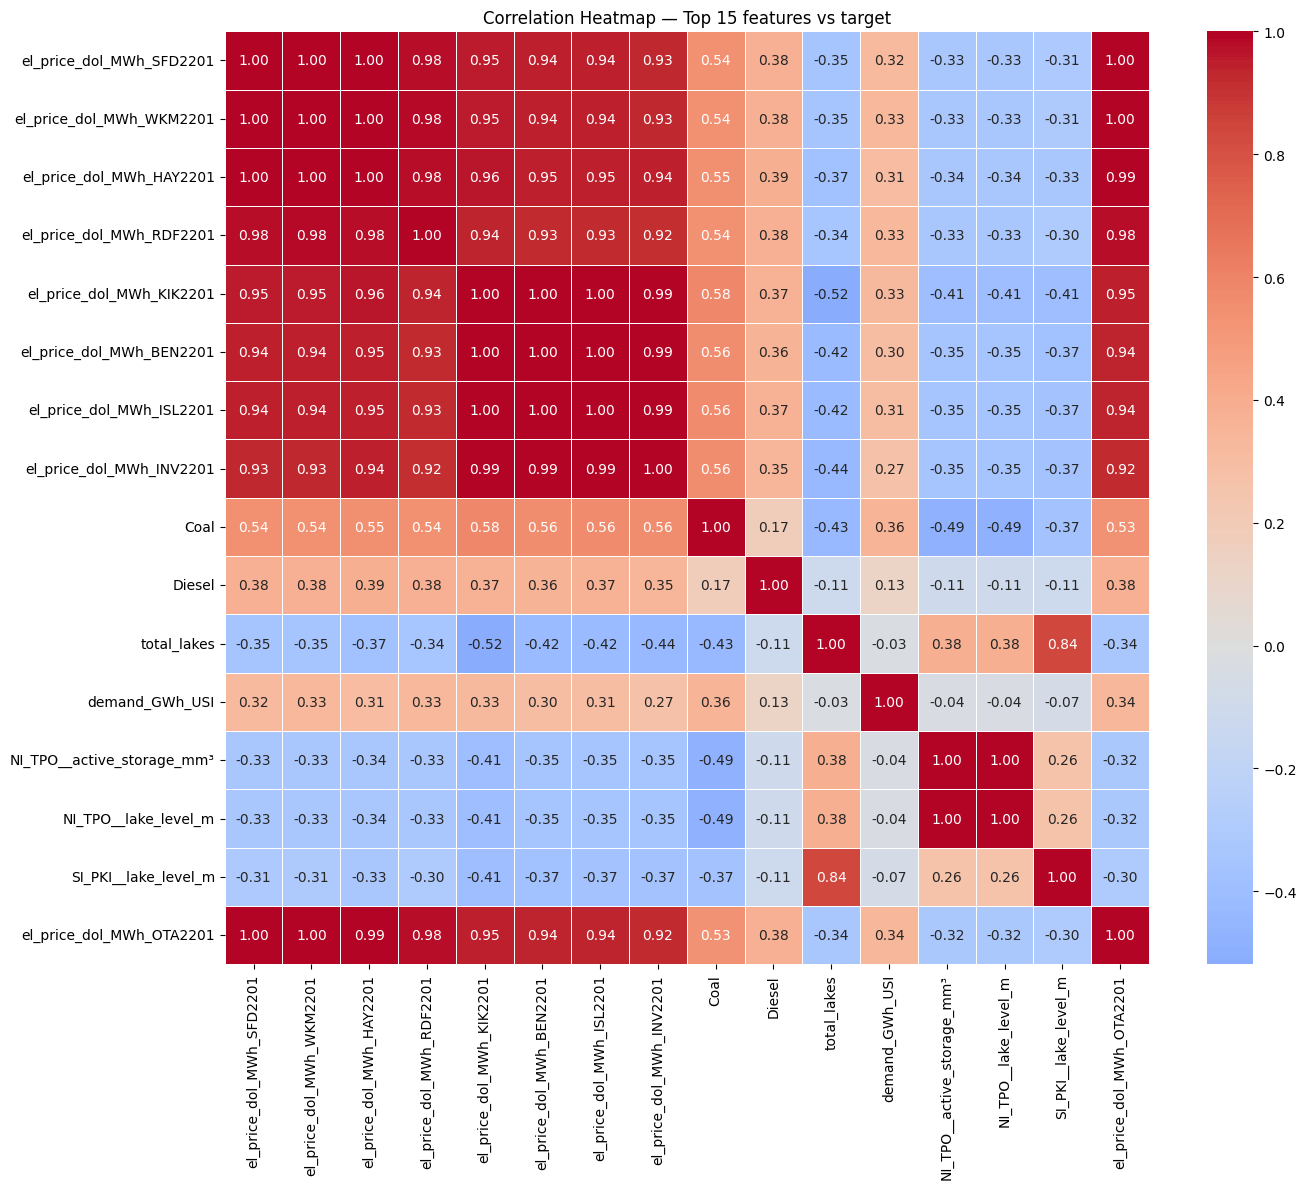

In [28]:
# Take top 15 most correlated (positive and negative)
top_cols = target_corr.abs().nlargest(15).index.tolist()
top_cols.append('el_price_dol_MWh_OTA2201')

plt.figure(figsize=(14, 12))
sns.heatmap(
    df[top_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Correlation Heatmap — Top 15 features vs target')
plt.tight_layout()
plt.show()

In [29]:
# --- Heatmap of feature-feature correlations ---
corr_matrix = df[features].corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, linewidths=0.3, vmin=-1, vmax=1)
plt.title('Feature-Feature Correlation Matrix')
plt.tight_layout()
plt.show()

NameError: name 'features' is not defined

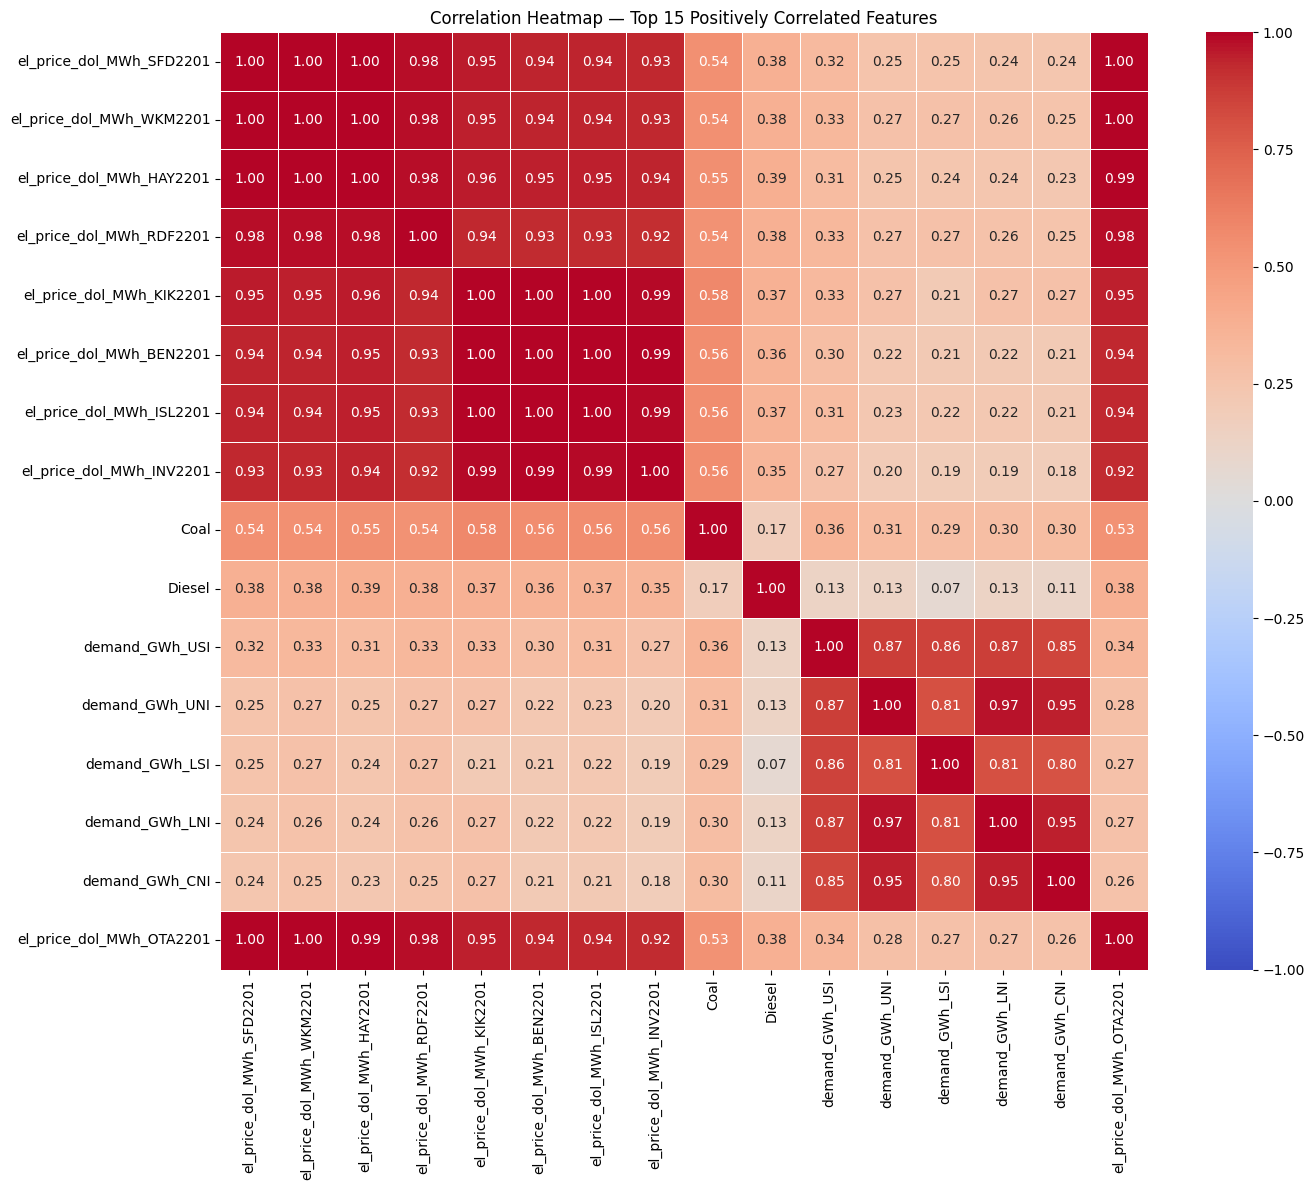

In [ ]:
# Top 15 most positively correlated
top_positive = target_corr.nlargest(15).index.tolist()
top_positive.append('el_price_dol_MWh_OTA2201')

plt.figure(figsize=(14, 12))
sns.heatmap(
    df[top_positive].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title('Correlation Heatmap — Top 15 Positively Correlated Features')
plt.tight_layout()
plt.show()

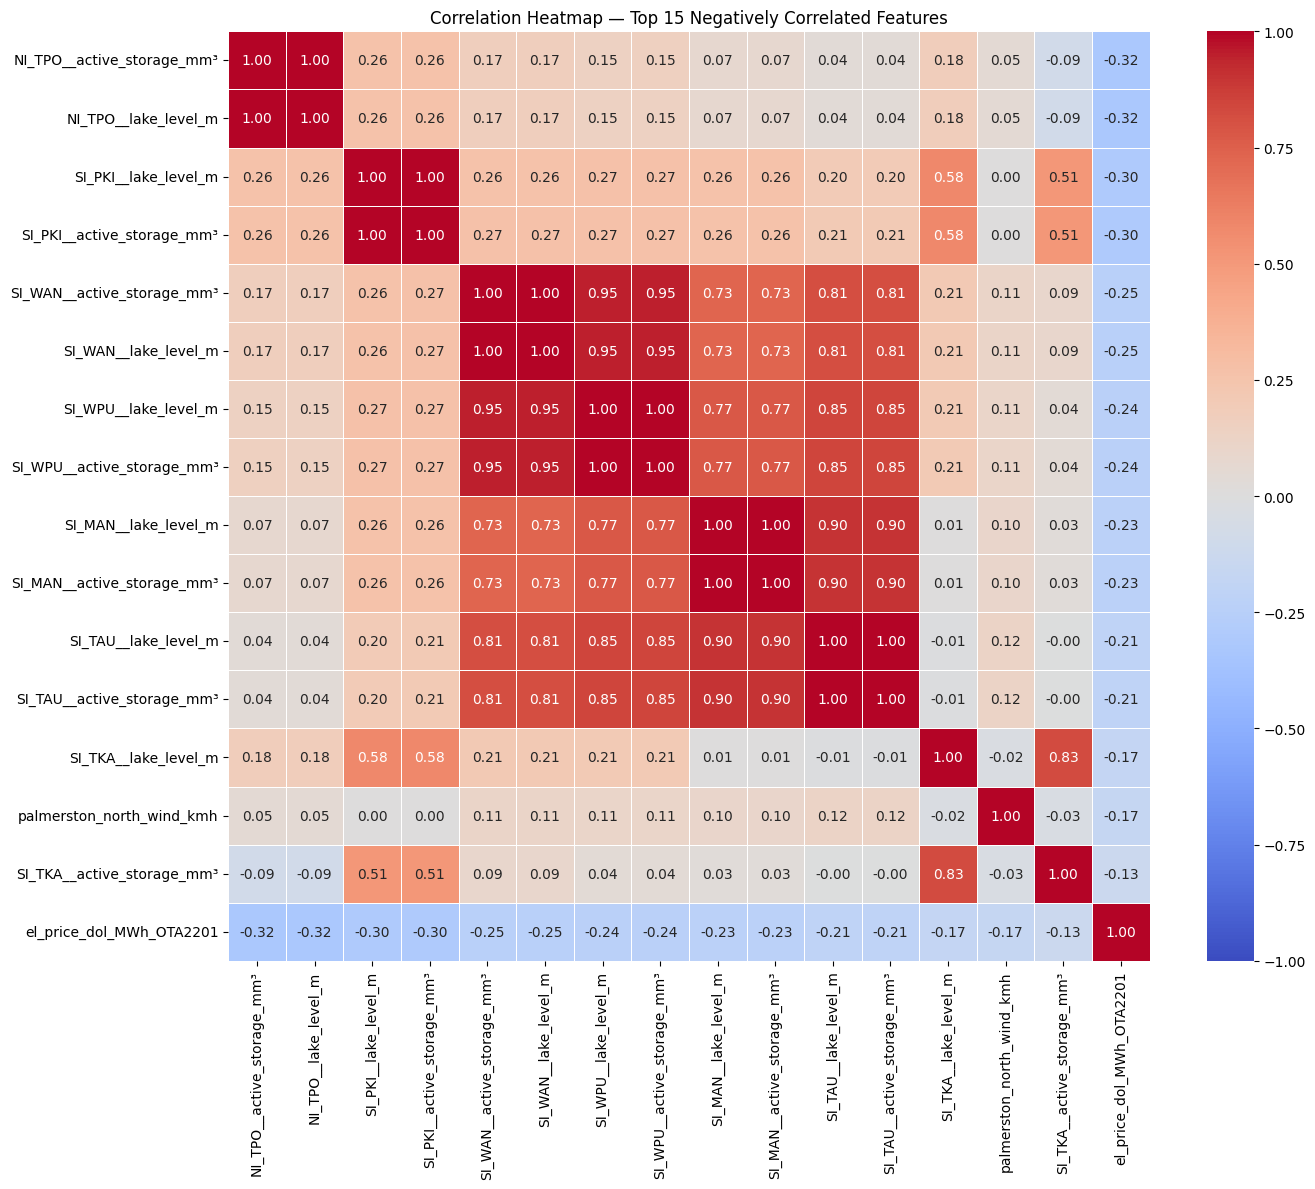

In [ ]:
# Top 15 most negatively correlated
top_negative = target_corr.nsmallest(15).index.tolist()
top_negative.append('el_price_dol_MWh_OTA2201')

plt.figure(figsize=(14, 12))
sns.heatmap(
    df[top_negative].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title('Correlation Heatmap — Top 15 Negatively Correlated Features')
plt.tight_layout()
plt.show()

## 4. Highly Correlated Pairs

In [ ]:
# --- Find highly correlated pairs (threshold 0.85) ---
threshold = 0.85
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'correlation'})
    .query('correlation >= @threshold')
    .sort_values('correlation', ascending=False)
)
print(f'Highly correlated pairs (>= {threshold}):')
print(high_corr_pairs.to_string(index=False))

Highly correlated pairs (>= 0.85):
                 feature_1                  feature_2  correlation
      NI_WKA__lake_level_m NI_WKA__active_storage_mm³     1.000000
      SI_MAN__lake_level_m SI_MAN__active_storage_mm³     1.000000
      SI_TAU__lake_level_m SI_TAU__active_storage_mm³     1.000000
      SI_WAN__lake_level_m SI_WAN__active_storage_mm³     1.000000
      NI_TPO__lake_level_m NI_TPO__active_storage_mm³     1.000000
      SI_WPU__lake_level_m SI_WPU__active_storage_mm³     1.000000
      SI_OHA__lake_level_m SI_OHA__active_storage_mm³     0.999999
      SI_HWE__lake_level_m SI_HWE__active_storage_mm³     0.999898
      SI_PKI__lake_level_m SI_PKI__active_storage_mm³     0.999882
  el_price_dol_MWh_ISL2201   el_price_dol_MWh_KIK2201     0.999797
  el_price_dol_MWh_BEN2201   el_price_dol_MWh_KIK2201     0.999272
  el_price_dol_MWh_BEN2201   el_price_dol_MWh_ISL2201     0.999247
  el_price_dol_MWh_HAY2201   el_price_dol_MWh_SFD2201     0.998080
  el_price_dol_MWh_SFD2201 

## 5. VIF - Test Multicollinearity

In [ ]:
vif_df = pd.DataFrame()
vif_df['feature'] = features
vif_df['VIF'] = [
    variance_inflation_factor(df[features].dropna().values, i)
    for i in range(len(features))
]
vif_df = vif_df.sort_values('VIF', ascending=False)

print(vif_df.to_string(index=False))
# Rule of thumb: VIF > 10 = serious multicollinearity, consider dropping
# VIF > 5 = moderate, worth investigating

                             feature          VIF
                NI_WKA__lake_level_m 1.579076e+07
          NI_WKA__active_storage_mm³ 1.579045e+07
          SI_MAN__active_storage_mm³ 8.947129e+06
                SI_MAN__lake_level_m 8.947102e+06
                SI_TAU__lake_level_m 6.189673e+06
          SI_TAU__active_storage_mm³ 6.189141e+06
                SI_WAN__lake_level_m 4.891788e+06
          SI_WAN__active_storage_mm³ 4.891724e+06
          NI_TPO__active_storage_mm³ 1.904375e+06
                NI_TPO__lake_level_m 1.904364e+06
                SI_WPU__lake_level_m 1.414601e+06
          SI_WPU__active_storage_mm³ 1.414406e+06
                SI_OHA__lake_level_m 5.058998e+05
          SI_OHA__active_storage_mm³ 5.058423e+05
            el_price_dol_MWh_ISL2201 1.220593e+04
          SI_HWE__active_storage_mm³ 9.710024e+03
                SI_HWE__lake_level_m 9.673145e+03
                SI_PKI__lake_level_m 7.829327e+03
          SI_PKI__active_storage_mm³ 7.779973e+03
